In [2]:
import pandas as pd
import numpy as np
import unicodedata
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
file_path_clean = '../tien_xy_ly/fulldata_clean_4web.csv'
df_eda = pd.read_csv(file_path_clean)

In [4]:
print(f"Đã đọc xong file: {file_path_clean}")
print(f"DataFrame EDA có shape: {df_eda.shape}")

Đã đọc xong file: ../tien_xy_ly/fulldata_clean_4web.csv
DataFrame EDA có shape: (116063, 19)


In [5]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116063 entries, 0 to 116062
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TieuDe         116063 non-null  object 
 1   Nguon          116063 non-null  object 
 2   ThanhPho       83006 non-null   object 
 3   QuanHuyen      116063 non-null  object 
 4   DiaChiFull     116063 non-null  object 
 5   NgayDang       116063 non-null  object 
 6   LoaiBDS        116063 non-null  object 
 7   Gia            116063 non-null  float64
 8   DienTich       116063 non-null  float64
 9   Gia_m2         116063 non-null  float64
 10  MatTien        116063 non-null  float64
 11  DuongVao       116063 non-null  float64
 12  ChieuRong      116063 non-null  float64
 13  ChieuDai       116063 non-null  float64
 14  SoTang         116063 non-null  float64
 15  SoPhongNgu     116063 non-null  float64
 16  SoPhongVeSinh  116063 non-null  float64
 17  SoPhongTam     116063 non-nul

In [6]:
if 'NgayDang' in df_eda.columns:
    df_eda['NgayDang'] = pd.to_datetime(df_eda['NgayDang'], errors='coerce')

In [7]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116063 entries, 0 to 116062
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TieuDe         116063 non-null  object        
 1   Nguon          116063 non-null  object        
 2   ThanhPho       83006 non-null   object        
 3   QuanHuyen      116063 non-null  object        
 4   DiaChiFull     116063 non-null  object        
 5   NgayDang       116063 non-null  datetime64[ns]
 6   LoaiBDS        116063 non-null  object        
 7   Gia            116063 non-null  float64       
 8   DienTich       116063 non-null  float64       
 9   Gia_m2         116063 non-null  float64       
 10  MatTien        116063 non-null  float64       
 11  DuongVao       116063 non-null  float64       
 12  ChieuRong      116063 non-null  float64       
 13  ChieuDai       116063 non-null  float64       
 14  SoTang         116063 non-null  float64       
 15  

## **1. Thống kê mô tả và phân tích các biến số chính**

### **1.Tính giá trị TB, Trung vị, min, max, độ lệch chuẩn và tứ phân vị**

In [8]:
#lấy các cột cần tính giá trị
cols = ['Gia', 'DienTich', 'Gia_m2']

# Tính các chỉ số thống kê cơ bản bằng hàm aggregate
stats = df_eda[cols].agg(['mean', 'median', 'min', 'max', 'std'])
# Tính thêm các tứ phân vị (quantiles)
stats.loc['25%'] = df_eda[cols].quantile(0.25)
stats.loc['50%'] = df_eda[cols].quantile(0.5)
stats.loc['75%'] = df_eda[cols].quantile(0.75)

display(stats)

,Gia,DienTich,Gia_m2
mean,1.569962e+10,121.217860,1.382221e+08
median,7.500000e+09,80.000000,1.000000e+08
min,1.330000e+08,1.000000,1.904762e+06
max,8.500000e+11,18000.000000,2.268519e+10
std,2.911841e+10,225.087429,3.954250e+08
25%,4.550000e+09,58.000000,6.208333e+07
50%,7.500000e+09,80.000000,1.000000e+08
75%,1.450000e+10,120.000000,1.596720e+08


### **1.1.Vẽ biểu đồ histogram để có thể nhận thấy rõ hơn phần nhận xét hơn**

#### **1.1.1. Giá**

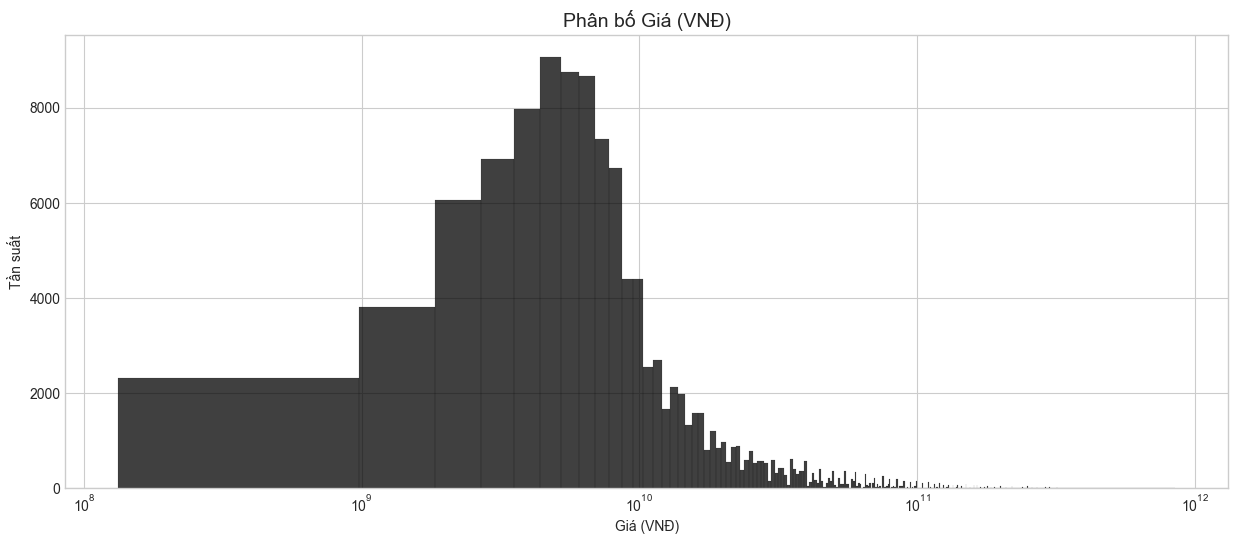

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 20))
plt.subplot(3, 1, 1)
sns.histplot(df_eda['Gia'], bins=1000, color='black')
plt.title('Phân bố Giá (VNĐ)', fontsize=14)
plt.xlabel('Giá (VNĐ)')
plt.ylabel('Tần suất')
plt.xscale('log' ) # dùng thang log vì giá trải dài từ 10^8 đến 10^12

* Nhận xét
    1. Giá trị Trung bình (15.7 tỷ) cao hơn trung vị (7.5 tỷ) → phân bố lệch phải, tức là phần lớn bất động sản có giá thấp, chỉ một số có giá cao hơn kéo trung bình lên.

    2. Khoảng giá phổ biến nằm trong khoảng từ 4.5 đến 14.5 tỷ đồng (Q1–Q3).

    3. Độ lệch chuẩn lớn (≈29 tỷ) cho thấy mức độ biến thiên còn đáng kể, song phần lớn dữ liệu vẫn tập trung quanh nhóm giá tầm trung.

    4. Biểu đồ cho thấy đỉnh phân bố nằm ở vùng 5–10 tỷ, tần suất giảm dần về phía giá cao.

#### **1.1.2.Diện tích**

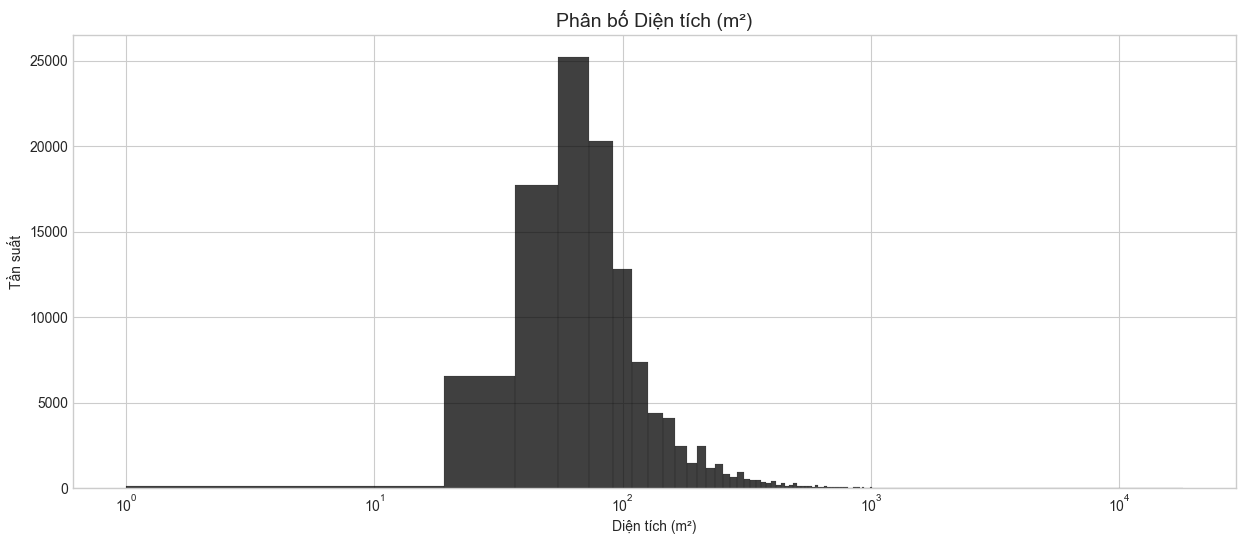

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 20))
plt.subplot(3, 1, 2)
sns.histplot(df_eda['DienTich'], bins=1000, color='black')
plt.title('Phân bố Diện tích (m²)', fontsize=14)
plt.xlabel('Diện tích (m²)')
plt.ylabel('Tần suất')
plt.xscale('log' )

* Nhận xét
    1. Giá trị Trung bình (121 m²) cao hơn trung vị (80 m²) → phân bố lệch phải.
    2. Phần lớn diện tích tập trung trong khoảng 58–120 m², tương ứng với nhà phố và căn hộ phổ thông.
    3. Độ lệch chuẩn 225 m² tương đối lớn, cho thấy sự đa dạng giữa các loại hình bất động sản (nhà phố, biệt thự, đất nền,…).
    4. Biểu đồ cho thấy phân bố có dạng “chuông lệch phải”, tập trung mạnh ở khu vực 50–150 m² và thưa dần khi diện tích tăng.
* Kết luận: Diện tích có phân bố lệch phải nhẹ, phần lớn bất động sản có diện tích nhỏ đến trung bình, phù hợp với đặc điểm đô thị.

#### **1.1.3.Giá/m2**

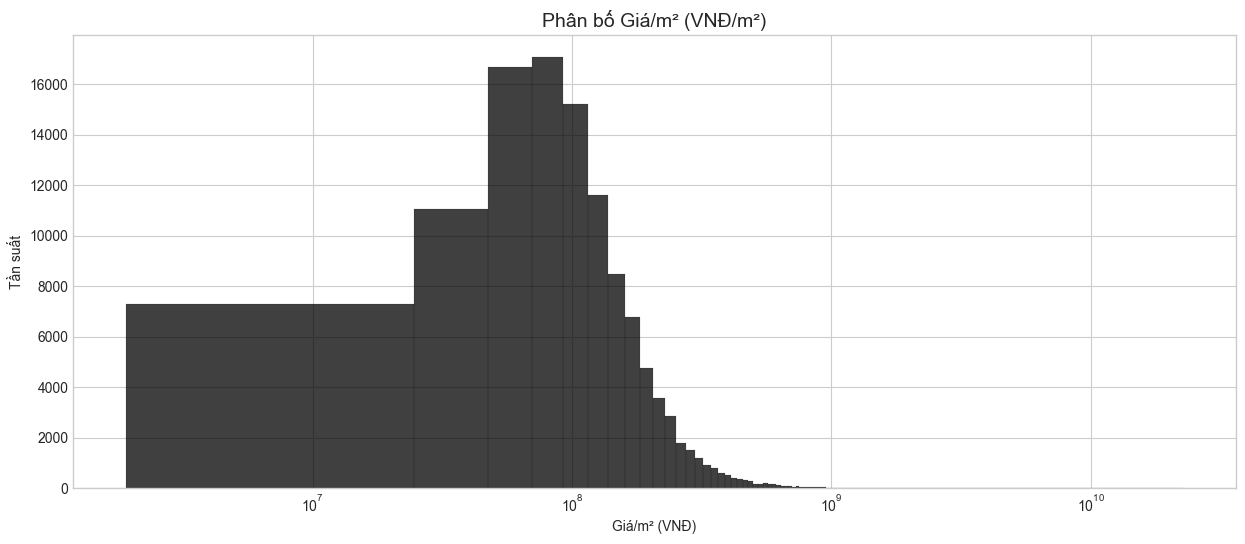

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 20))
plt.subplot(3, 1, 3)
sns.histplot(df_eda['Gia_m2'], bins=1000, color='black')
plt.title('Phân bố Giá/m² (VNĐ/m²)', fontsize=14)
plt.xlabel('Giá/m² (VNĐ)')
plt.ylabel('Tần suất')
plt.xscale('log')

* Nhận xét
    1. Trung bình 138 triệu/m² cao hơn trung vị 100 triệu/m² → phân bố lệch phải nhẹ.
 
    2. Khoảng giá phổ biến rơi vào vùng 62–160 triệu/m², phù hợp với phân khúc trung và cao cấp tại các đô thị lớn.

    3. Độ lệch chuẩn 395 triệu/m² khá cao, phản ánh sự khác biệt giữa các khu vực (vị trí trung tâm và vùng ven).

    4. Biểu đồ cho thấy đỉnh phân bố rõ ràng ở vùng từ 60–150 triệu/m², sau đó tần suất giảm dần.

* Kết luận: Giá/m² có phân bố lệch phải nhẹ, tập trung ở nhóm trung bình – cao, phản ánh rõ sự chênh lệch giá giữa các khu vực khác nhau.

## **2. Thống kê mô tả và phân tích các biến số phụ**

### **2.1. Tính thống kê mô tả cho các biến số phụ**

In [12]:
# Chọn các cột cần phân tích
cols_secondary_numeric = [
    'MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai',
    'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe'
]
# Lọc ra các cột thực sự tồn tại trong df_eda
cols_secondary_numeric = [col for col in cols_secondary_numeric if col in df_eda.columns]

display(df_eda[cols_secondary_numeric].describe().T)

,count,mean,std,min,25%,50%,75%,max
MatTien,116063.0,733.298453,249086.059341,0.0,0.0,0.0,0.0,84858689.0
DuongVao,116063.0,2.711913,25.387739,0.0,0.0,0.0,3.0,6000.0
ChieuRong,116063.0,0.441415,2.216429,0.0,0.0,0.0,0.0,101.0
ChieuDai,116063.0,1.348159,7.465932,0.0,0.0,0.0,0.0,1310.0
SoTang,116063.0,0.581581,2.506278,0.0,0.0,0.0,0.0,330.0
SoPhongNgu,116063.0,2.352197,5.158587,0.0,0.0,2.0,4.0,710.0
SoPhongVeSinh,116063.0,1.896263,3.503980,0.0,0.0,1.0,3.0,168.0
SoPhongTam,116063.0,0.106313,0.833802,0.0,0.0,0.0,0.0,80.0
ChoDeXe,116063.0,0.078018,0.268201,0.0,0.0,0.0,0.0,1.0


* Nhận xét:
    * Bảng thống kê cho thấy các cột `MatTien`, `DuongVao`, `ChieuRong`, `ChieuDai`, `SoTang`, `SoPhongTam`, `ChoDeXe` có giá trị `median` (50%) bằng 0. Điều này khẳng định rằng phần lớn dữ liệu gốc bị thiếu và đã được điền bằng 0 ở bước tiền xử lý.

### **2.2 Trực quan hóa phân bố cho Mặt tiền, Đường vào, Chiều rộng, Chiều dài**

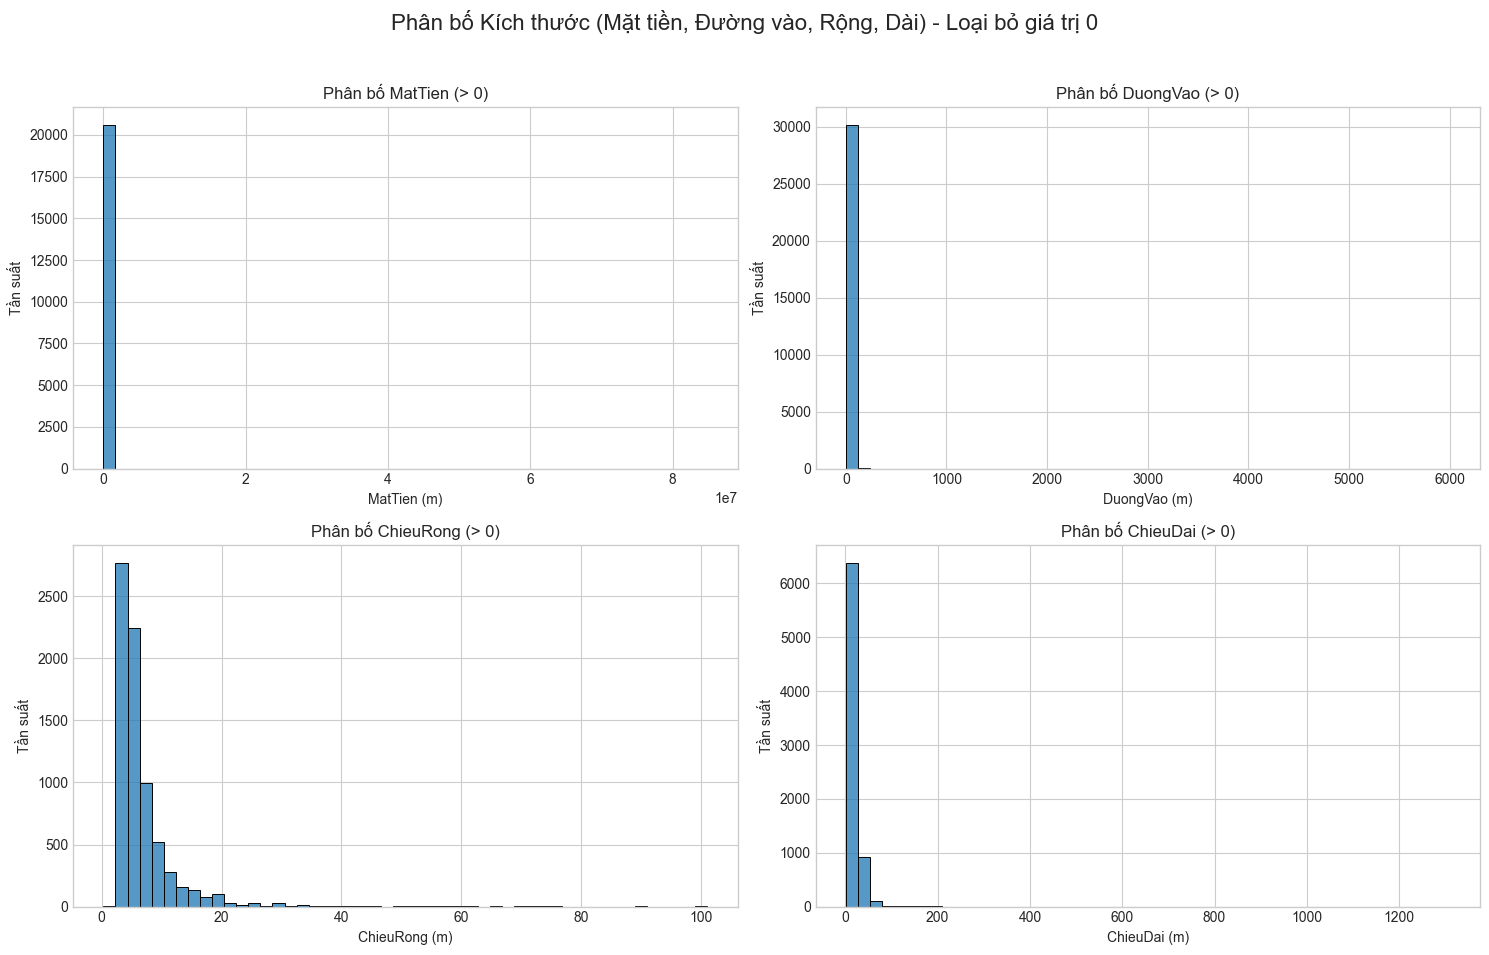

In [13]:
# (Lọc bỏ giá trị 0 để xem phân bố thực tế tốt hơn)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Phân bố Kích thước (Mặt tiền, Đường vào, Rộng, Dài) - Loại bỏ giá trị 0', fontsize=16)

cols_dims = ['MatTien', 'DuongVao', 'ChieuRong', 'ChieuDai']
axes = axes.flatten() # Chuyển axes thành mảng 1D để dễ lặp

for i, col in enumerate(cols_dims):
    if col in df_eda.columns:
        # Lấy dữ liệu > 0
        data_filtered = df_eda[df_eda[col] > 0][col]
        if not data_filtered.empty:
            sns.histplot(data_filtered, bins=50, kde=False, ax=axes[i])
            axes[i].set_title(f'Phân bố {col} (> 0)')
            axes[i].set_xlabel(f'{col} (m)')
            axes[i].set_ylabel('Tần suất')

        else:
             axes[i].set_title(f'{col} (không có dữ liệu > 0)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) 
plt.show()

* Nhận xét:
    * Biểu đồ histogram (khi đã lọc giá trị 0) cho thấy phân bố của `MatTien`, `DuongVao`, `ChieuRong`, `ChieuDai` đều bị lệch phải
    

### **2.3 Trực quan hóa tuần suất cho Số tầng, Số phòng ngủ, Số phòng vệ sinh, Số phòng tắm, Chỗ để xe**

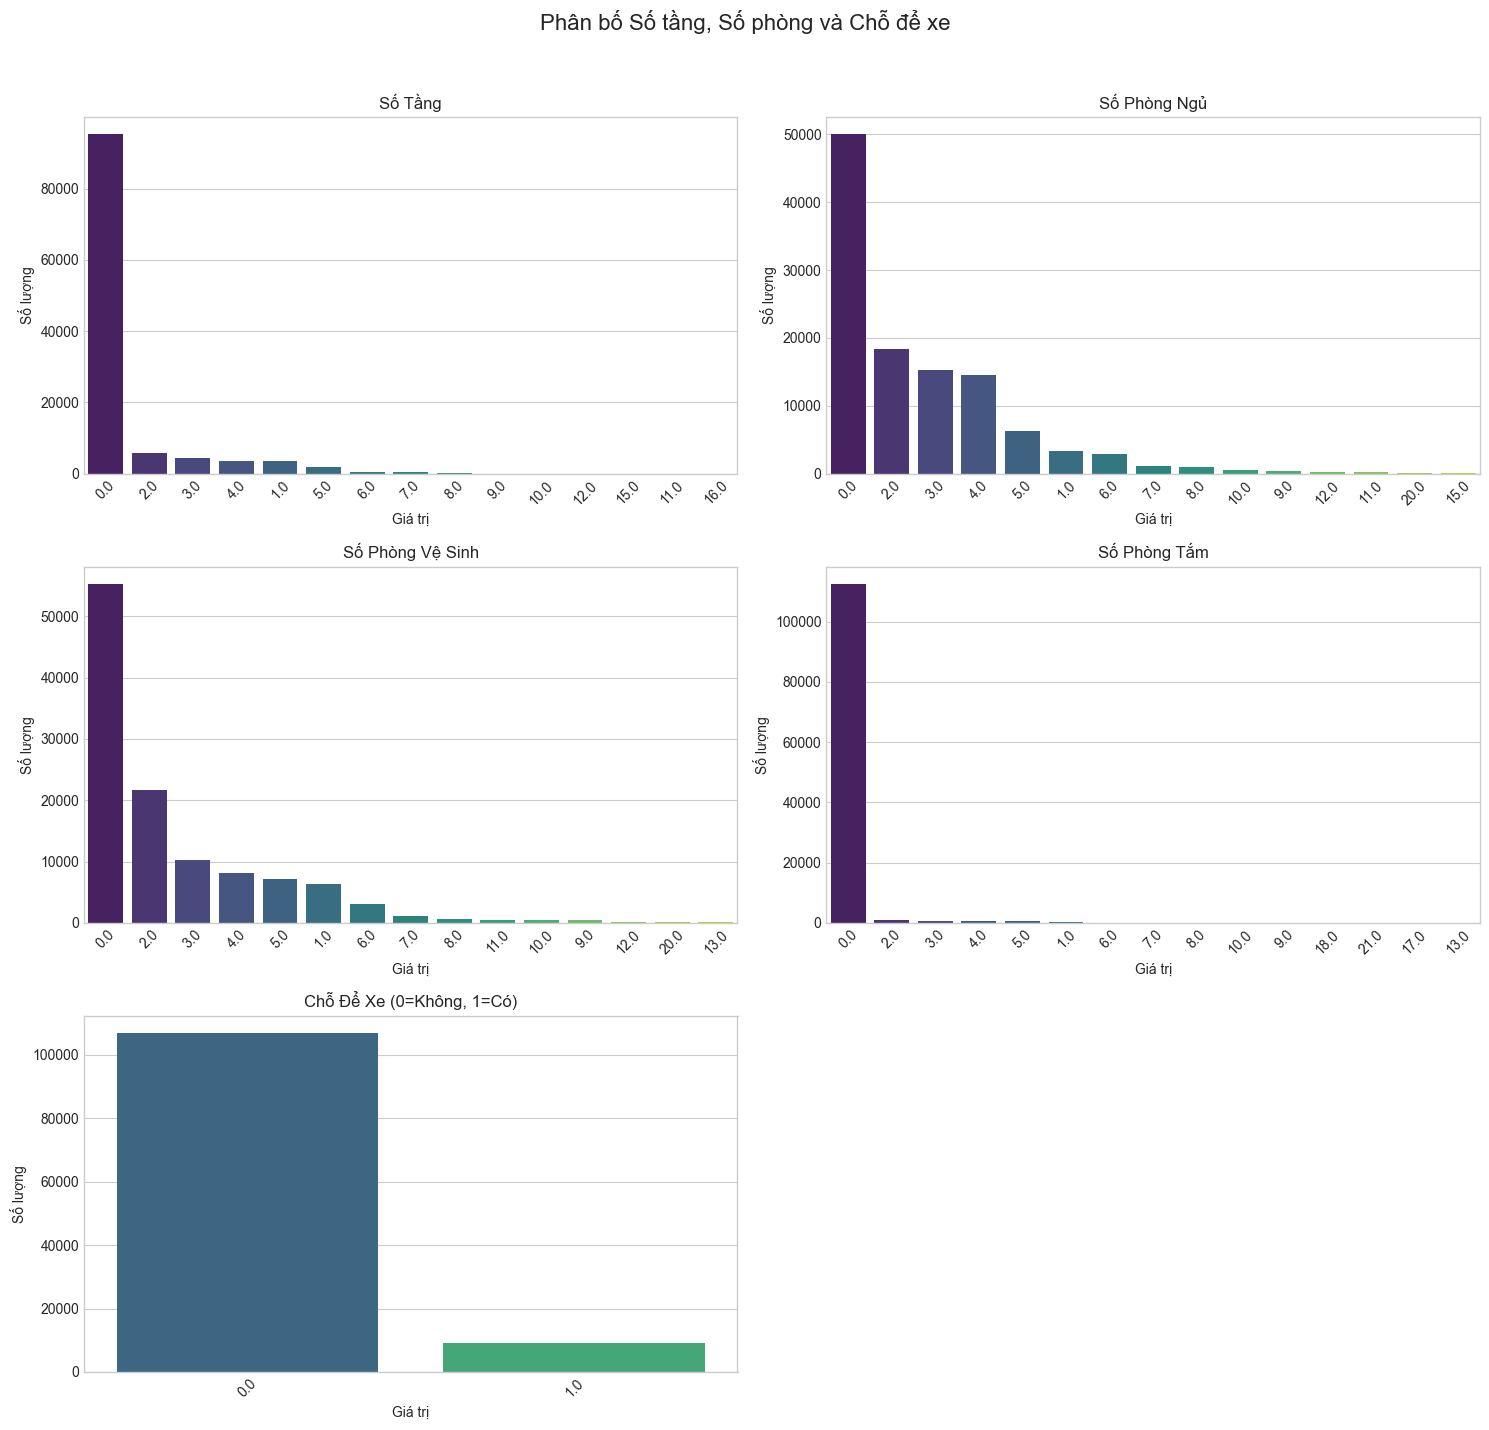

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15)) # Tăng kích thước và số hàng
fig.suptitle('Phân bố Số tầng, Số phòng và Chỗ để xe', fontsize=16)
axes = axes.flatten()

cols_counts = ['SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe']
titles = ['Số Tầng', 'Số Phòng Ngủ', 'Số Phòng Vệ Sinh', 'Số Phòng Tắm', 'Chỗ Để Xe (0=Không, 1=Có)']

for i, col in enumerate(cols_counts):
     if col in df_eda.columns:
        # Giới hạn số lượng giá trị hiển thị nếu quá nhiều (vd: SoPhongNgu)
        order = df_eda[col].value_counts().iloc[:15].index # Lấy top 15 giá trị phổ biến
        sns.countplot(x=col, data=df_eda, ax=axes[i], order=order, palette='viridis')
        axes[i].set_title(titles[i])
        axes[i].set_xlabel('Giá trị')
        axes[i].set_ylabel('Số lượng')
        axes[i].tick_params(axis='x', rotation=45)
     else:
         axes[i].set_title(f'{titles[i]} (Cột không tồn tại)')

# Ẩn subplot cuối cùng nếu không dùng
if len(cols_counts) < len(axes):
    for j in range(len(cols_counts), len(axes)):
        fig.delaxes(axes[j])


plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

* Nhận xét:
    * Biểu đồ đếm (countplot) cho thấy rõ ràng giá trị 0là phổ biến nhất ở hầu hết các cột này 
    * Khi loại bỏ giá trị 0, `SoTang` phổ biến nhất là 2, 4, 3, 1 tầng.
    * `SoPhongNgu` phổ biến nhất là 2, 3, 4 phòng.
    * `SoPhongVeSinh` phổ biến là 2, 1, 3 phòng.
    * `SoPhongTam` và `ChoDeXe` có số lượng giá trị 0 ( vì dữ liệu thiếu quá nhiều)

## **3. Phân tích các biến phân loại**

### **3.1 Thống kê tuần suất**


In [15]:


print("\n--- Thống kê tần suất cho các biến phân loại ---")
print("\n Phân bố cho cột: QuanHuyen")
col = 'QuanHuyen'
if col in df_eda.columns:
    counts_qh = df_eda[col].value_counts()
    percentages_qh = df_eda[col].value_counts(normalize=True) * 100
    
    # Tạo DataFrame để hiển thị đẹp hơn
    stats_qh = pd.DataFrame({'SoLuong': counts_qh, 'TyLe_%': percentages_qh.round(2)})
    
    # Hiển thị tất cả các hạng mục
    display(stats_qh)
else:
    print(f" Cột '{col}' không tồn tại.")


--- Thống kê tần suất cho các biến phân loại ---

 Phân bố cho cột: QuanHuyen


,SoLuong,TyLe_%
QuanHuyen,,
Thủ Đức,26524,22.85
Tân Bình,8641,7.45
Bình Tân,8485,7.31
Gò Vấp,8077,6.96
Quận 7,7613,6.56
Quận 12,7478,6.44
Bình Thạnh,7462,6.43
Tân Phú,7117,6.13
Bình Chánh,4482,3.86


In [16]:
print("\n Phân bố cho cột: LoaiBDS")
col = 'LoaiBDS'
if col in df_eda.columns:
    counts_lb = df_eda[col].value_counts()
    percentages_lb = df_eda[col].value_counts(normalize=True) * 100
    
    stats_lb = pd.DataFrame({'SoLuong': counts_lb, 'TyLe_%': percentages_lb.round(2)})
    
    # Hiển thị tất cả các hạng mục
    display(stats_lb)
else:
    print(f" Cột '{col}' không tồn tại.")


 Phân bố cho cột: LoaiBDS


,SoLuong,TyLe_%
LoaiBDS,,
Nhà,65661,56.57
Đất,22355,19.26
Căn hộ,11615,10.01
Không xác định,11478,9.89
Biệt thự,4954,4.27


In [17]:
print("\n Phân bố cho cột: Nguon")
col = 'Nguon'
if col in df_eda.columns:
    counts_ng = df_eda[col].value_counts()
    percentages_ng = df_eda[col].value_counts(normalize=True) * 100
    
    stats_ng = pd.DataFrame({'SoLuong': counts_ng, 'TyLe_%': percentages_ng.round(2)})
    
    # Hiển thị tất cả các hạng mục
    display(stats_ng)
else:
    print(f" Cột '{col}' không tồn tại.")


 Phân bố cho cột: Nguon


,SoLuong,TyLe_%
Nguon,,
batdongsan,68602,59.11
nhadat24h,33057,28.48
alonhadat,8088,6.97
meeyland,6316,5.44


### **3.2 Trực quan hóa các biến phân loại**

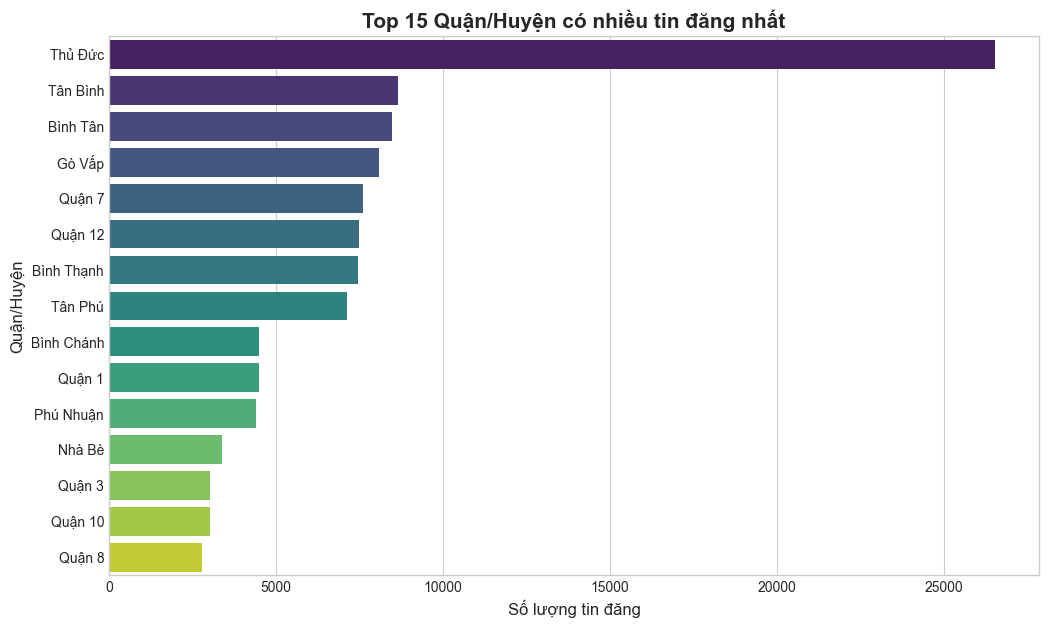

In [18]:
# 3.2.1. Biểu đồ cho QuanHuyen (Top 15)

plt.figure(figsize=(12, 7))
# Lấy top 15 quận huyện phổ biến nhất
top_15_quan = df_eda['QuanHuyen'].value_counts().iloc[:15].index
sns.countplot(y='QuanHuyen', data=df_eda, order=top_15_quan, palette='viridis')
plt.title('Top 15 Quận/Huyện có nhiều tin đăng nhất', fontsize=15, weight='bold')
plt.xlabel('Số lượng tin đăng', fontsize=12)
plt.ylabel('Quận/Huyện', fontsize=12)
plt.show()

* Nhận xét
    * Biểu đồ Top 15 cho thấy sự phân bố tin đăng không đồng đều giữa các quận.
    * Thành phố Thủ Đức là khu vực có số lượng tin đăng cao vượt trội (hơn 25.000 tin), nhiều hơn gấp đôi so với quận đứng thứ hai là Tân Bình.
    * Các quận/huyện còn lại: Tân Bình, Bình Tân, Gò Vấp, Quận 7, Quận 12, Bình Thạnh, Tân Phú có số lượng đăng tin xem xem nhau ( khoảng 7000 - 9000 tin)
    * Các quận Bình Chánh, Quận 1, Phú Nhuận, Nhà Bè, Quận 3, Quận 10, Quận 8 số lượng thấp (dưới 5000 tin)

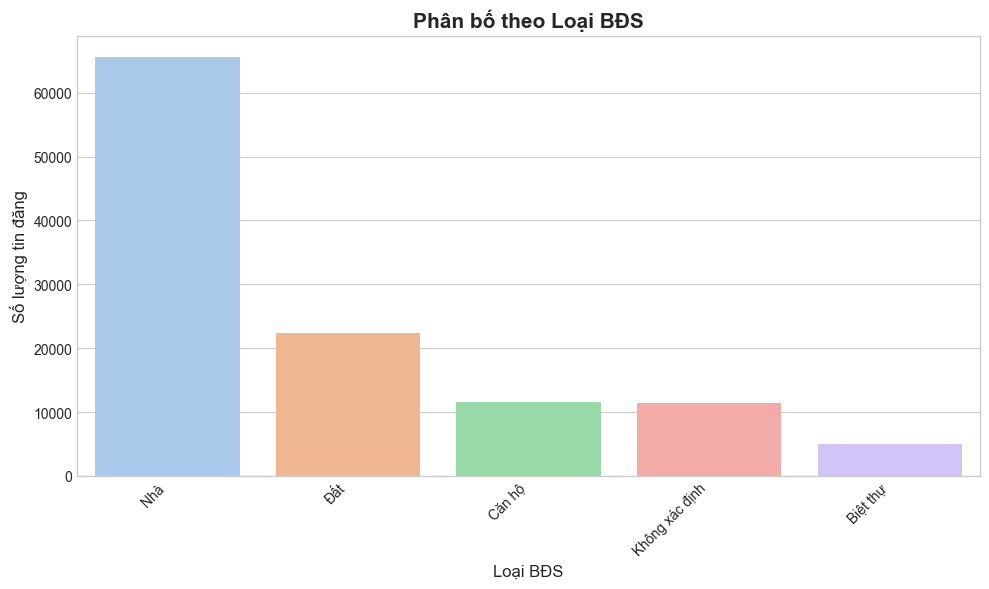

In [19]:
# 3.2.2. Biểu đồ cho LoaiBDS

plt.figure(figsize=(10, 6)) 
sns.countplot(x='LoaiBDS', data=df_eda, palette='pastel', order=df_eda['LoaiBDS'].value_counts().index)
plt.title('Phân bố theo Loại BĐS', fontsize=15, weight='bold')
plt.xlabel('Loại BĐS', fontsize=12)
plt.ylabel('Số lượng tin đăng', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

* Nhận xét
    * Loại hình "Nhà" chiếm đa số tuyệt đối trong tập dữ liệu, với số lượng cao hơn hẳn các loại hình khác (hơn 60.000 tin)
    * "Đất" là loại hình phổ biến thứ hai (hơn 20.000 tin), tiếp theo là "Căn hộ", "Không xác định"và "Biệt thự" chiếm tỷ lệ nhỏ nhất (dưới 12.000 tin)

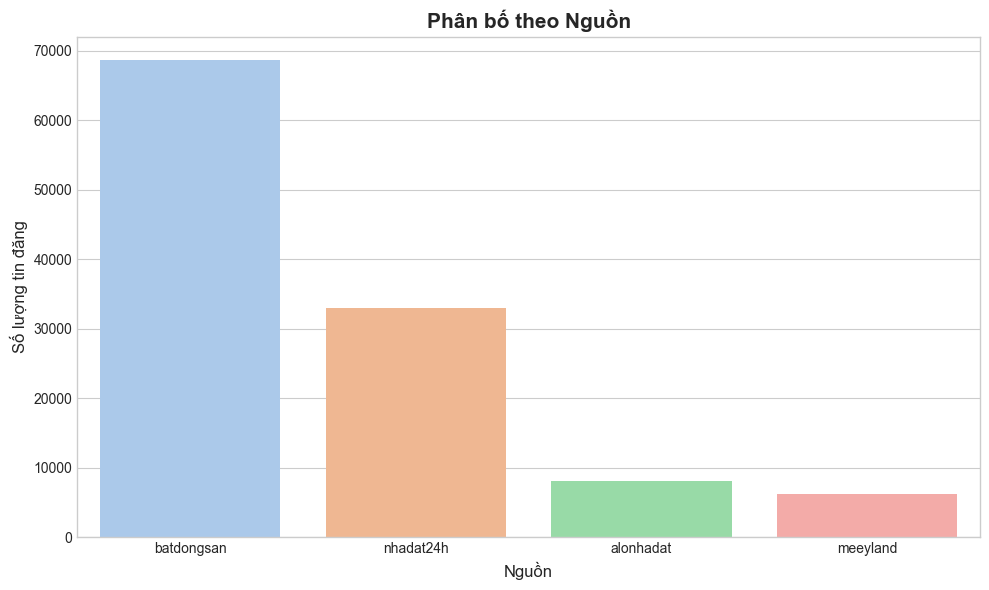

In [20]:
# 3.2.3. Biểu đồ cho Nguon

plt.figure(figsize=(10, 6)) 
sns.countplot(x='Nguon', data=df_eda, palette='pastel', order=df_eda['Nguon'].value_counts().index)
plt.title('Phân bố theo Nguồn', fontsize=15, weight='bold')
plt.xlabel('Nguồn', fontsize=12)
plt.ylabel('Số lượng tin đăng', fontsize=12)
plt.tight_layout()
plt.show()

* Nhận xét
    * Nguồn batdongsan đóng góp lượng dữ liệu lớn nhất, chiếm hơn một nửa tổng số tin đăng (gần 70.000 tin)
    * nhadat24h là nguồn lớn thứ hai (hơn 30.000 tin), theo sau là alonhadat và meeyland với số lượng ít hơn đáng kể (dưới 10.000 tin)

## **4. Phân tích mối quan hệ giữa các biến số**

### **4.1 Tạo Ma trận tương quan**

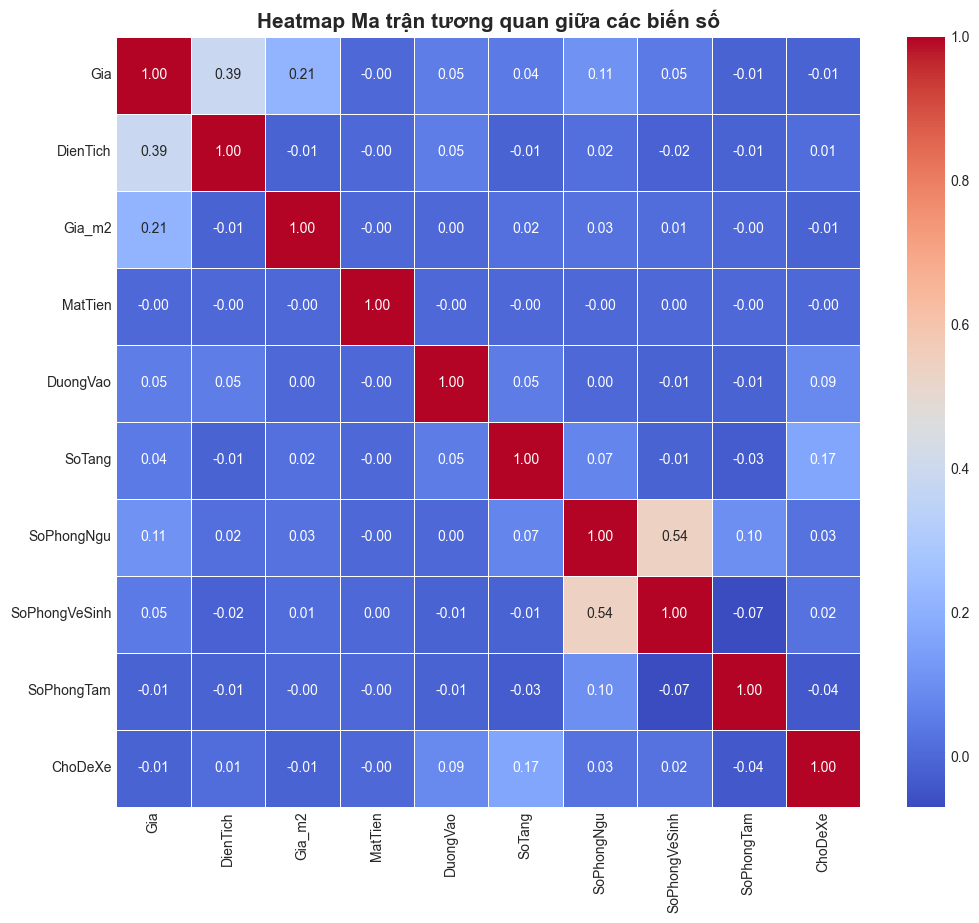


 Mối tương quan với 'Gia' 


Gia              1.000000
DienTich         0.389137
Gia_m2           0.212223
SoPhongNgu       0.107634
DuongVao         0.054282
SoPhongVeSinh    0.045693
SoTang           0.044879
MatTien         -0.001281
ChoDeXe         -0.011092
SoPhongTam      -0.012210
Name: Gia, dtype: float64

In [24]:
numeric_cols_for_corr = [
    'Gia', 'DienTich', 'Gia_m2', 'MatTien', 'DuongVao', 
    'SoTang', 'SoPhongNgu', 'SoPhongVeSinh', 'SoPhongTam', 'ChoDeXe'
]
# Lọc lại các cột tồn tại trong df_eda
numeric_cols_for_corr = [col for col in numeric_cols_for_corr if col in df_eda.columns]

# Tính toán ma trận tương quan
corr_matrix = df_eda[numeric_cols_for_corr].corr()

# Trực quan hóa ma trận bằng Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True,        
    cmap='coolwarm',  
    fmt='.2f',           
    linewidths=.5      
)
plt.title('Heatmap Ma trận tương quan giữa các biến số', fontsize=15, weight='bold')
plt.show()

# Hiển thị các mối tương quan cao nhất/thấp nhất với 'Gia'
print("\n Mối tương quan với 'Gia' ")
corr_gia = corr_matrix['Gia'].sort_values(ascending=False)
display(corr_gia)

* Dựa trên Heatmap và danh sách tương quan, ta có các nhận xét sau:

* **Tương quan với `Gia` (Giá bán):**
    * **`DienTich`:** Có mối tương quan dương **trung bình** ($r \approx 0.39$). Đây là yếu tố có mối quan hệ tuyến tính rõ ràng nhất với `Gia`.
    * **Các biến còn lại:** Hầu hết các biến khác (`SoPhongNgu`, `DuongVao`, `MatTien`...) có mức tương quan **rất yếu hoặc gần như bằng 0** (từ -0.01 đến 0.11). Nguyên nhân chính là do các cột này có **tỷ lệ giá trị 0 rất cao** (do thiếu thông tin gốc và đã được điền 0), làm loãng mối tương quan tuyến tính.

* **Đa cộng tuyến (Tương quan giữa các biến độc lập):**
    * Cặp `SoPhongNgu` và `SoPhongVeSinh` có tương quan dương **trung bình** ($r = 0.54$). Điều này logic (nhà nhiều phòng ngủ thường có nhiều phòng vệ sinh) và cần được lưu ý khi xây dựng mô hình.

### **4.2 Trực quan hóa Tương quan: Giá vs. Diện tích (Scatter Plot)**

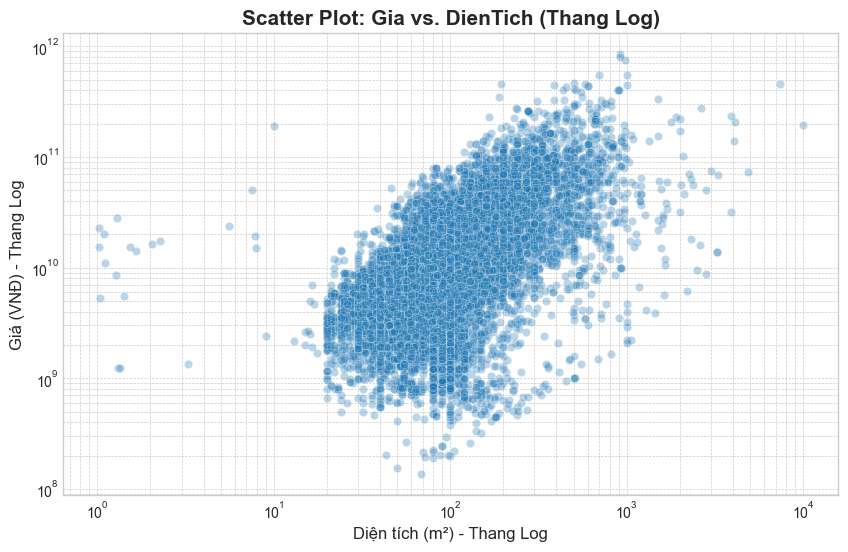

In [25]:
# Dùng log scale cho cả 2 trục vì chúng đều bị lệch phải
plt.figure(figsize=(10, 6))
# Lấy 20000 mẫu để biểu đồ rõ hơn
df_sample = df_eda.sample(n=min(20000, len(df_eda)), random_state=42) 

sns.scatterplot(data=df_sample, x='DienTich', y='Gia', alpha=0.3)
plt.title('Scatter Plot: Gia vs. DienTich (Thang Log)', fontsize=15, weight='bold')
plt.xlabel('Diện tích (m²) - Thang Log', fontsize=12)
plt.ylabel('Giá (VNĐ) - Thang Log', fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

* Nhận xét 

* Biểu đồ scatter plot (sau khi dùng thang log cho cả 2 trục) cho thấy một mối tương quan **dương rõ rệt**.
* Các điểm dữ liệu tập trung thành một đám mây đi lên từ trái sang phải, khẳng định lại kết luận từ ma trận tương quan: **Diện tích càng lớn thì tổng giá bán có xu hướng càng cao**.


### **4.3 . Trực quan hóa Mối quan hệ: Giá vs. Số Phòng Ngủ (Boxplot)**

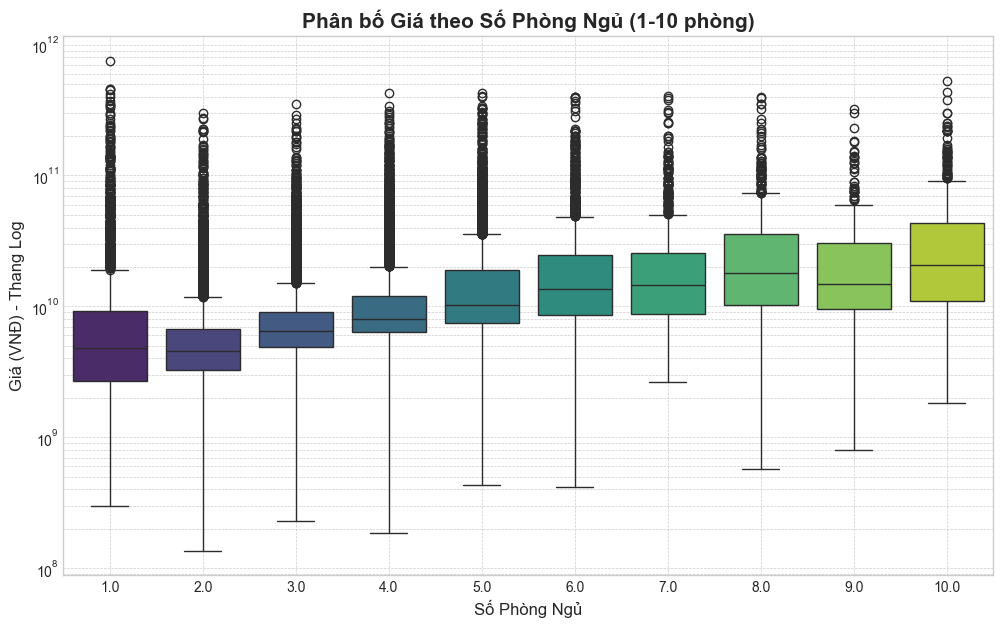

In [ ]:
# Vì SoPhongNgu là biến rời rạc, dùng boxplot sẽ tốt hơn scatterplot
# Chỉ xem xét các BĐS có số phòng ngủ từ 1 đến 10 (lọc bỏ giá trị 0 và quá lớn)
plt.figure(figsize=(12, 7))
data_phongngu_filtered = df_eda[(df_eda['SoPhongNgu'] > 0) & (df_eda['SoPhongNgu'] <= 10)]
sns.boxplot(data=data_phongngu_filtered, x='SoPhongNgu', y='Gia', palette='viridis')
plt.title('Phân bố Giá theo Số Phòng Ngủ (1-10 phòng)', fontsize=15, weight='bold')
plt.xlabel('Số Phòng Ngủ', fontsize=12)
plt.ylabel('Giá (VNĐ) - Thang Log', fontsize=12)
plt.yscale('log') # Vẫn dùng thang log cho Giá
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

* Nhận xét

* Biểu đồ boxplot (sau khi lọc các giá trị 0 và >10) cho thấy một xu hướng **tích cực** rõ rệt.
* Giá nhà (trung vị - đường kẻ ngang trong hộp) có xu hướng **tăng dần** khi số phòng ngủ tăng từ 1 đến khoảng 5-6 phòng.
* Ở các mức phòng ngủ cao hơn (7-10 phòng), giá có vẻ biến động mạnh hơn (hộp dài hơn), có thể do đây là các loại BĐS đặc thù hoặc số lượng mẫu ít hơn.
* Điều này cho thấy `SoPhongNgu` là một yếu tố dự đoán tốt hơn so với con số tương quan tuyến tính (0.11) thể hiện.

## **5. Phân tích mối quan hệ giữa biến Phân loại và biến số (tập trung vào giá)**

* Mục tiêu
    - So sánh Giá / Giá_m2 giữa các Quận và giữa các Loại BĐS 
    - Tính giá trung bình & trung vị theo Quận và theo Loại BĐS
    - Vẽ heatmap trung vị theo (LoạiBDS x Quận)


### **5.1 So sánh Giá giữa các quận**

Số quận đủ dữ liệu (>=30): 22


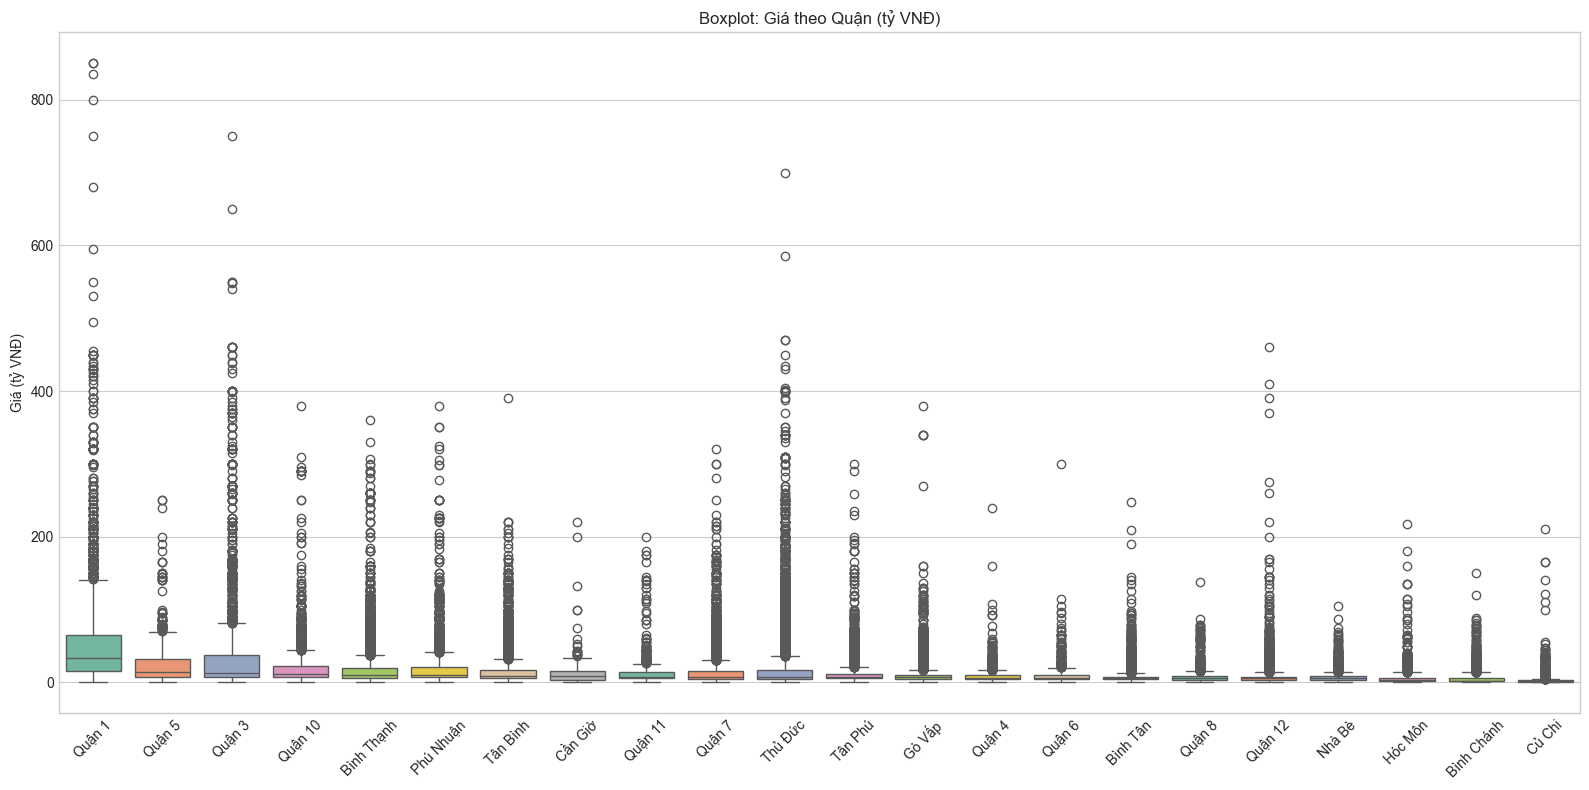

In [ ]:
# Lọc quận đủ mẫu
quan_counts = df_eda['QuanHuyen'].value_counts()
quan_valid = quan_counts[quan_counts >= 30].index.tolist()
df_quan_plot = df_eda[df_eda['QuanHuyen'].isin(quan_valid) & (df_eda['Gia'] > 0)].copy()
df_quan_plot['Gia_ty'] = df_quan_plot['Gia'] / 1e9

print(f"Số quận đủ dữ liệu (>=30): {len(quan_valid)}")

# Vẽ boxplot (top theo median để thứ tự trực quan)
order_quan = df_quan_plot.groupby('QuanHuyen')['Gia'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_quan_plot, x='QuanHuyen', y='Gia_ty', order=order_quan, palette='Set2')
plt.title('Boxplot: Giá theo Quận (tỷ VNĐ)')
plt.xlabel('')
plt.ylabel('Giá (tỷ VNĐ)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Nhận xét: 

* Biểu đồ cho thấy có sự chênh lệch giá giữa các quận. 

* Quận 1, 3, 5 có giá trung vị cao nhất, phản ánh vị trí trung tâm.

* Các quận ngoại thành (Củ Chi, Hóc Môn, Bình Chánh) có giá thấp hơn đáng kể.

* Quận 1 và 3 có nhiều outliers nhất, cho thấy có nhiều BĐS cao cấp với giá trị đặc biệt cao (lên tới 800+ tỷ).

### **5.2 So sánh Giá giữa các loại BĐS**

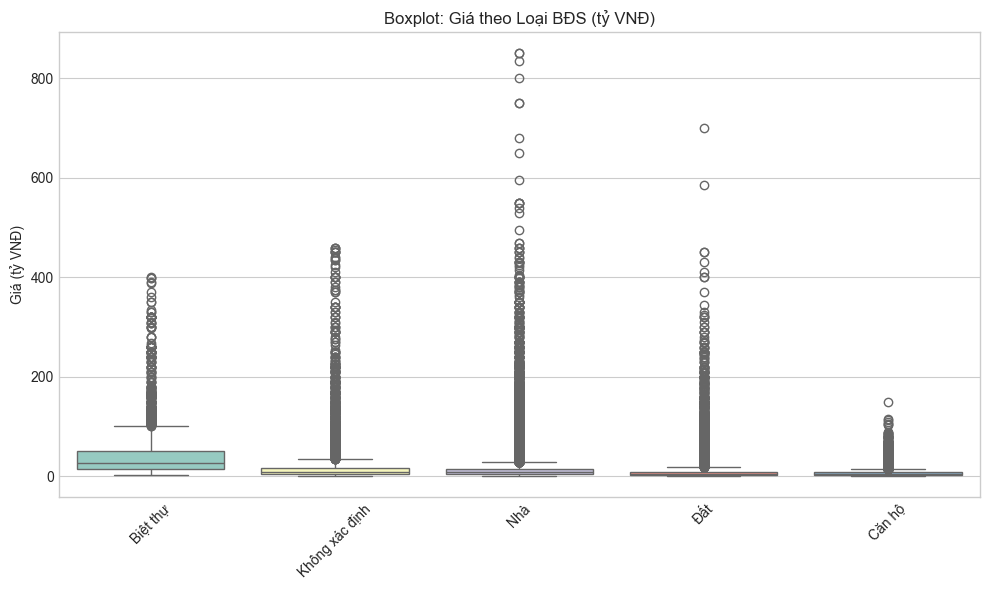

In [ ]:
df_loai_plot = df_eda[df_eda['LoaiBDS'].notna() & (df_eda['Gia'] > 0)].copy()
df_loai_plot['Gia_ty'] = df_loai_plot['Gia'] / 1e9
order_loai = df_loai_plot.groupby('LoaiBDS')['Gia'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_loai_plot, x='LoaiBDS', y='Gia_ty', order=order_loai, palette='Set3')
plt.title('Boxplot: Giá theo Loại BĐS (tỷ VNĐ)')
plt.xlabel('')
plt.ylabel('Giá (tỷ VNĐ)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Nhận xét: 

* Biệt thự có giá trung vị cao nhất (khoảng 40-50 tỷ), phản ánh đây là loại BĐS cao cấp

* Nhà và Đất có giá trung vị thấp nhất (khoảng 20-30 tỷ) nhưng lại có nhiều outliers nhất, với giá trị cao nhất lên tới 800+ tỷ

* Căn hộ có giá trung vị thấp nhất và ít outliers nhất, cho thấy mức giá tương đối ổn định

* Không xác định được loại BĐS cũng có nhiều giá trị bất thường, phạm vi giá rất rộng

### **5.3 Thống kê Giá trung bình và trung vị theo Quận và theo loại BĐS**

Thống kê theo Quận (sắp theo Giá trung vị):


,So_luong,Gia_TB,Gia_TrungVi,Gia_STD,Gia_TrungVi_ty
QuanHuyen,,,,,
Quận 1,4479,5.425668e+10,3.300000e+10,6.878406e+10,33.00
Quận 5,1016,2.511766e+10,1.400000e+10,3.003188e+10,14.00
Quận 3,3022,3.925002e+10,1.250000e+10,6.996557e+10,12.50
Quận 10,3022,2.046232e+10,1.100000e+10,2.905651e+10,11.00
Bình Thạnh,7462,1.901105e+10,9.950000e+09,2.840121e+10,9.95
Phú Nhuận,4397,1.929521e+10,9.500000e+09,2.859687e+10,9.50
Tân Bình,8641,1.619199e+10,8.950000e+09,2.124209e+10,8.95
Cần Giờ,236,1.466411e+10,8.175000e+09,2.420639e+10,8.18
Quận 11,857,1.451325e+10,7.900000e+09,2.255278e+10,7.90


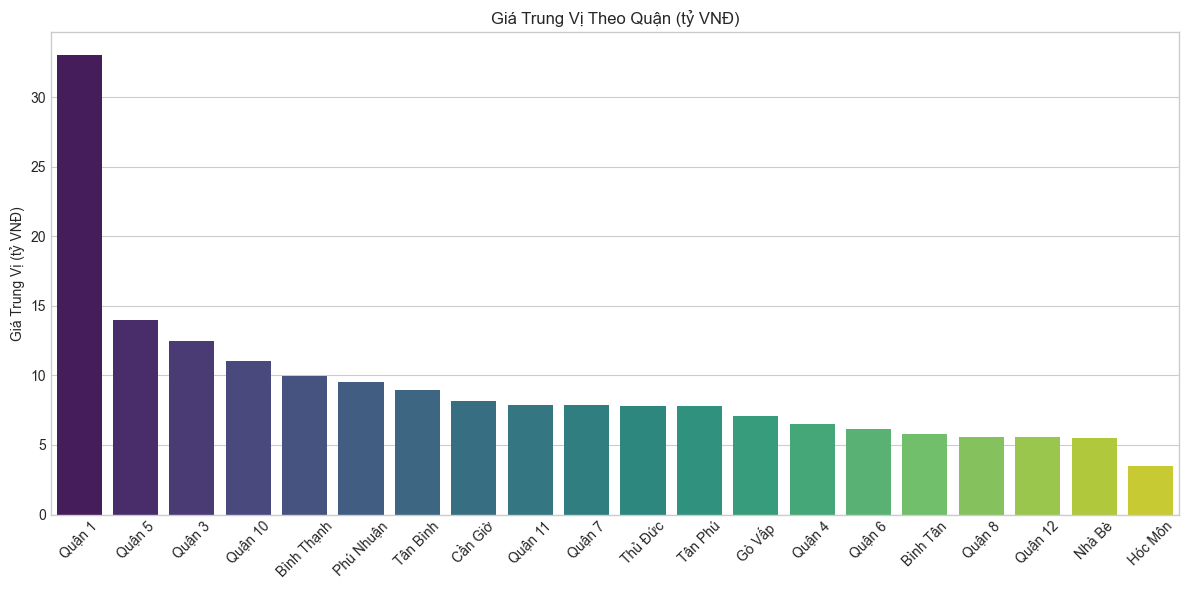

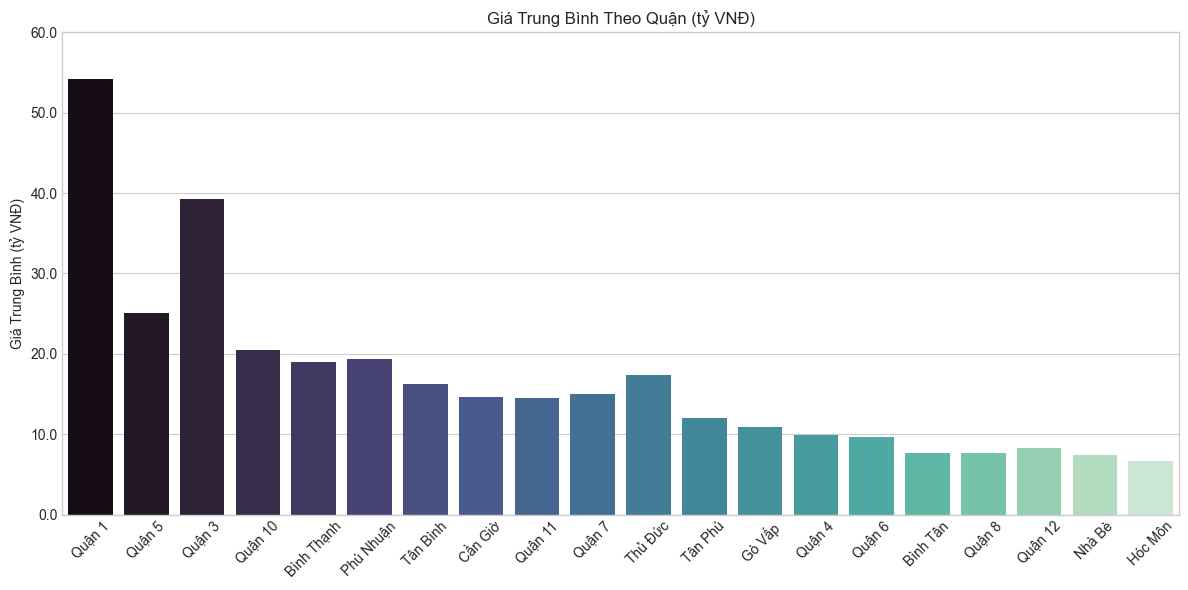

In [ ]:
# --- Thống kê theo Quận ---
gia_theo_quan = df_eda[df_eda['Gia'] > 0].groupby('QuanHuyen').agg(
    So_luong=('Gia', 'count'),
    Gia_TB=('Gia', 'mean'),
    Gia_TrungVi=('Gia', 'median'),
    Gia_STD=('Gia', 'std')
).sort_values('Gia_TrungVi', ascending=False).round(0)

gia_theo_quan['Gia_TrungVi_ty'] = gia_theo_quan['Gia_TrungVi'] / 1e9

print("Thống kê theo Quận (sắp theo Giá trung vị):")
display(gia_theo_quan.head(20).round(2))

# --- Vẽ biểu đồ ---
plt.figure(figsize=(12, 6))
sns.barplot(data=gia_theo_quan.reset_index().head(20),
            x='QuanHuyen', y='Gia_TrungVi_ty', palette='viridis')
plt.title('Giá Trung Vị Theo Quận (tỷ VNĐ)')
plt.ylabel('Giá Trung Vị (tỷ VNĐ)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# --- Vẽ biểu đồ Giá Trung Bình theo Quận ---
plt.figure(figsize=(12, 6))
sns.barplot(data=gia_theo_quan.reset_index().head(20),
            x='QuanHuyen', y='Gia_TB', palette='mako')

plt.title('Giá Trung Bình Theo Quận (tỷ VNĐ)')
plt.ylabel('Giá Trung Bình (tỷ VNĐ)')
plt.xlabel('')
plt.xticks(rotation=45)

# Chuyển sang đơn vị tỷ VNĐ
yticks = plt.yticks()[0]
plt.yticks(yticks, [f'{y/1e9:.1f}' for y in yticks])

plt.tight_layout()
plt.show()

Nhận xét: 

* Trung bình luôn cao hơn trung vị ở tất cả các quận, cho thấy dữ liệu có phân phối lệch phải

* Quận 1 có chênh lệch lớn nhất (trung vị 33 tỷ vs trung bình 54 tỷ), phản ánh có nhiều BĐS siêu cao cấp kéo giá trung bình lên

* Các quận trung tâm (Quận 1, 5, 3) có độ chênh lệch cao hơn quận ngoại thành, cho thấy thị trường đa dạng hơn về phân khúc

* Các quận ngoại thành có chênh lệch nhỏ hơn, thị trường BĐS tương đối đồng đều

* Trung vị phản ánh chính xác hơn mức giá điển hình mà người mua thường gặp, trong khi trung bình bị ảnh hưởng bởi các BĐS giá trị cao bất thường

Thống kê theo Loại BĐS:


,So_luong,Gia_TB,Gia_TrungVi,Gia_STD,Gia_TrungVi_ty,Gia_TB_ty
LoaiBDS,,,,,,
Biệt thự,4954,4.107275e+10,2.700000e+10,4.443310e+10,27.00,41.07
Không xác định,11478,1.959471e+10,8.500000e+09,3.643186e+10,8.50,19.59
Nhà,65661,1.629506e+10,7.990000e+09,2.897488e+10,7.99,16.30
Đất,22355,1.081585e+10,4.960000e+09,2.375240e+10,4.96,10.82
Căn hộ,11615,7.061870e+09,4.500000e+09,8.666507e+09,4.50,7.06


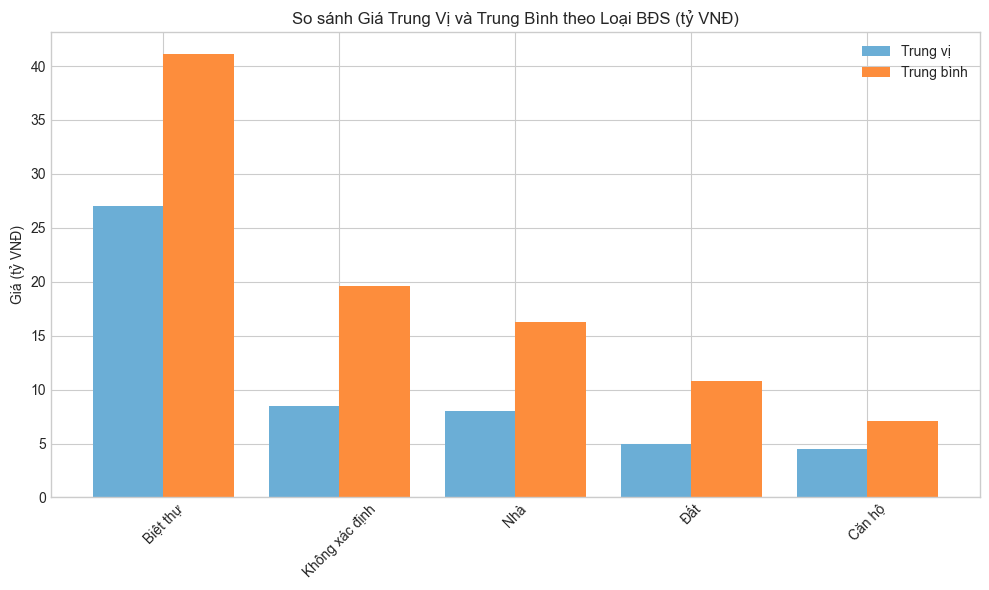

In [ ]:
# --- Thống kê theo Loại BĐS ---
gia_theo_loai = df_eda[df_eda['Gia'] > 0].groupby('LoaiBDS').agg(
    So_luong=('Gia', 'count'),
    Gia_TB=('Gia', 'mean'),
    Gia_TrungVi=('Gia', 'median'),
    Gia_STD=('Gia', 'std')
).sort_values('Gia_TrungVi', ascending=False).round(0)

gia_theo_loai['Gia_TrungVi_ty'] = gia_theo_loai['Gia_TrungVi'] / 1e9
gia_theo_loai['Gia_TB_ty'] = gia_theo_loai['Gia_TB'] / 1e9

print("Thống kê theo Loại BĐS:")
display(gia_theo_loai.round(2))

# --- Vẽ biểu đồ so sánh Trung Vị & Trung Bình ---
plt.figure(figsize=(10, 6))
x = np.arange(len(gia_theo_loai))
bar_width = 0.4

plt.bar(x - bar_width/2, gia_theo_loai['Gia_TrungVi_ty'], 
        width=bar_width, label='Trung vị', color='#6baed6')
plt.bar(x + bar_width/2, gia_theo_loai['Gia_TB_ty'], 
        width=bar_width, label='Trung bình', color='#fd8d3c')

plt.xticks(x, gia_theo_loai.index, rotation=45)
plt.title('So sánh Giá Trung Vị và Trung Bình theo Loại BĐS (tỷ VNĐ)')
plt.ylabel('Giá (tỷ VNĐ)')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

Nhận xét: 

* Giá Trung Bình luôn cao hơn Giá Trung Vị ở tất cả các loại BĐS, cho thấy dữ liệu có phân phối lệch phải do tồn tại các giao dịch giá cực cao.

* Biệt Thự: Có giá trị trung vị (median) cao nhất (khoảng 27 tỷ VNĐ) và chênh lệch lớn nhất (Trung bình - Trung vị), phản ánh phân khúc cao cấp và sự đa dạng về giá trị.

* Căn Hộ: Có giá trị trung vị thấp nhất (khoảng 4.5 tỷ VNĐ) và chênh lệch nhỏ nhất, cho thấy phân khúc này có tính đồng đều về giá cao nhất.

*  Ý nghĩa: Giá Trung Vị phản ánh chính xác hơn mức giá điển hình của từng loại hình BĐS, ít bị ảnh hưởng bởi các giao dịch ngoại lai (outliers) có giá trị cao bất thường.

### **5.4 Phân tích Giá/m2: so sánh theo Quận và theo loại BĐS**

In [ ]:
df_giam2 = df_eda[df_eda['Gia_m2']>0].copy()
df_giam2['Gia_m2_trieu'] = df_giam2['Gia_m2'] / 1e6

giam2_theo_quan = df_giam2.groupby('QuanHuyen').agg(
    So_luong=('Gia_m2','count'),
    Gia_m2_TB=('Gia_m2','mean'),
    Gia_m2_TrungVi=('Gia_m2','median')
).sort_values('Gia_m2_TrungVi', ascending=False).round(0)

print("Top 10 Quận theo Giá/m² (trung vị):")
display(giam2_theo_quan.head(10).assign(Gia_m2_TrungVi_trieu=lambda d: d['Gia_m2_TrungVi']/1e6).round(2))

giam2_theo_loai = df_giam2.groupby('LoaiBDS').agg(
    So_luong=('Gia_m2','count'),
    Gia_m2_TB=('Gia_m2','mean'),
    Gia_m2_TrungVi=('Gia_m2','median')
).sort_values('Gia_m2_TrungVi', ascending=False).round(0)

print("Giá/m² theo Loại BĐS:")
display(giam2_theo_loai.assign(Gia_m2_TrungVi_trieu=lambda d: d['Gia_m2_TrungVi']/1e6).round(2))


Top 10 Quận theo Giá/m² (trung vị):


,So_luong,Gia_m2_TB,Gia_m2_TrungVi,Gia_m2_TrungVi_trieu
QuanHuyen,,,,
Quận 1,4479,374011548.0,322320709.0,322.32
Quận 5,1016,251659747.0,221951220.0,221.95
Quận 3,3022,262556062.0,217186218.0,217.19
Quận 10,3022,220065510.0,201851852.0,201.85
Phú Nhuận,4397,198881171.0,181132075.0,181.13
Quận 11,857,162082684.0,150602410.0,150.60
Bình Thạnh,7462,159834036.0,146666667.0,146.67
Tân Bình,8641,151160560.0,140000000.0,140.00
Gò Vấp,8077,119643007.0,113580247.0,113.58


Giá/m² theo Loại BĐS:


,So_luong,Gia_m2_TB,Gia_m2_TrungVi,Gia_m2_TrungVi_trieu
LoaiBDS,,,,
Biệt thự,4954,177843798.0,139728718.0,139.73
Nhà,65661,152189558.0,121875000.0,121.88
Không xác định,11478,238838953.0,102363971.0,102.36
Căn hộ,11615,73478620.0,60240964.0,60.24
Đất,22355,70394586.0,57142857.0,57.14


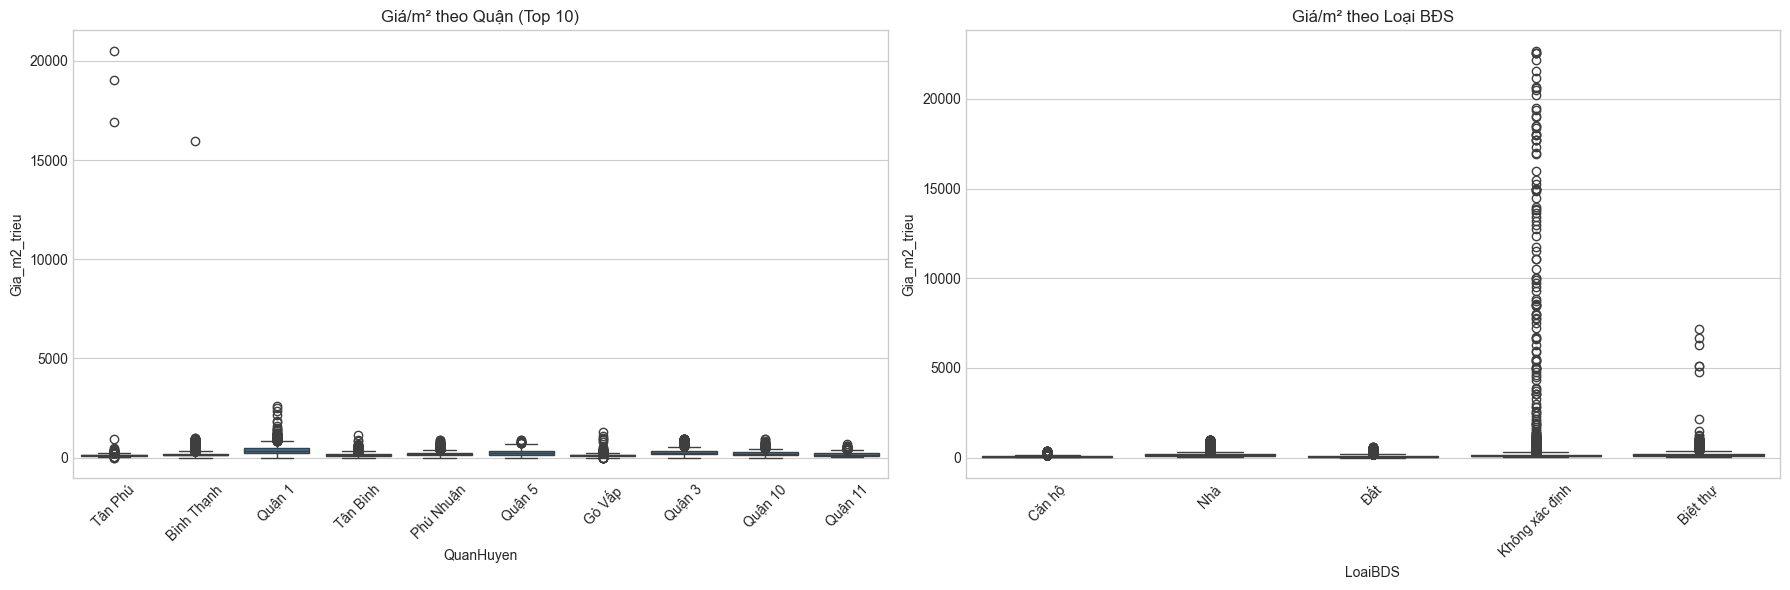

In [ ]:
# Vẽ boxplot Giá/m² cho top 10 quận và các loại
fig, axes = plt.subplots(1, 2, figsize=(18,6))
top10_quan_giam2 = giam2_theo_quan.head(10).index.tolist()
sns.boxplot(data=df_giam2[df_giam2['QuanHuyen'].isin(top10_quan_giam2)], x='QuanHuyen', y='Gia_m2_trieu', ax=axes[0])
axes[0].set_title('Giá/m² theo Quận (Top 10)'); axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_giam2[df_giam2['LoaiBDS'].notna()], x='LoaiBDS', y='Gia_m2_trieu', ax=axes[1])
axes[1].set_title('Giá/m² theo Loại BĐS'); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

Nhận xét:

##### Giá/m² theo Quận (Top 10):

* Tân Phú, Bình Thạnh và Quận 1 có nhiều outliers với giá/m² cực cao (15.000-20.000 triệu/m²)

* Phần lớn các quận có giá/m² trung vị khá đồng đều (khoảng 200-400 triệu/m²)

* Quận 1 có độ phân tán lớn nhất, cho thấy sự chênh lệch giá trị BĐS trong cùng quận

##### Giá/m² theo Loại BĐS:

* "Không xác định" có giá/m² cao nhất và nhiều outliers nhất (lên tới 20.000+ triệu/m²)

* Biệt thự có độ phân tán lớn với nhiều giá trị bất thường

* Căn hộ, Nhà, Đất có giá/m² tương đối ổn định và đồng đều

* Sự chênh lệch giữa các loại BĐS không quá lớn về giá trung vị, nhưng biệt thự và loại không xác định có giá trị cao cực đoan

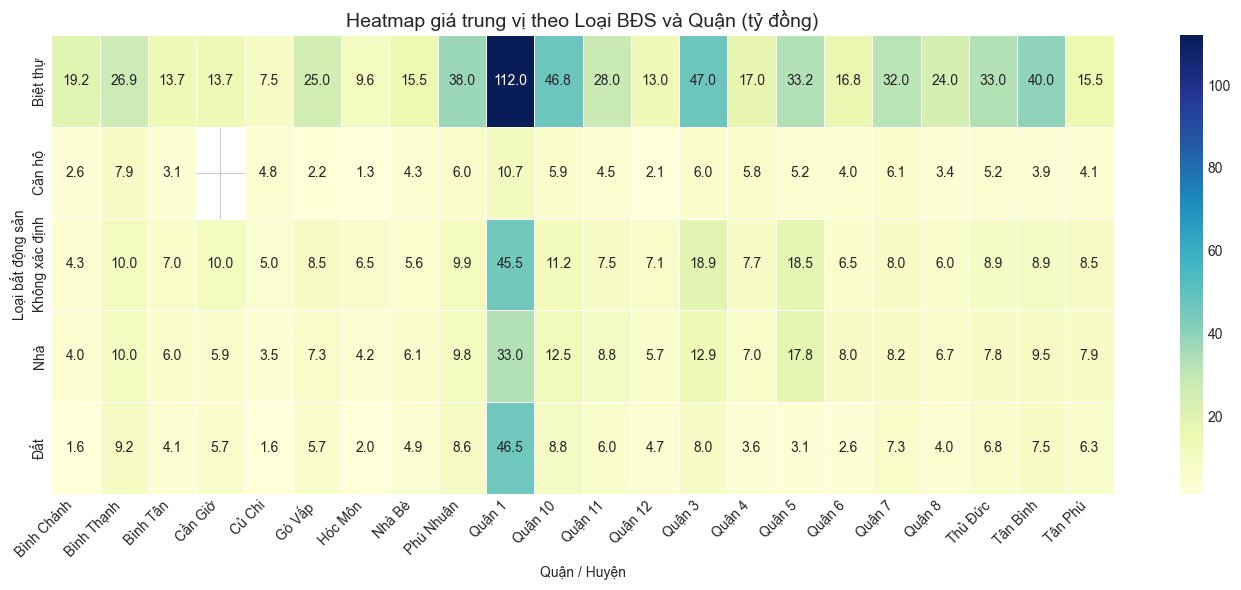

In [ ]:
df_filtered = df_eda[df_eda['Gia'] > 0]

# Tạo bảng pivot: hàng là loại BĐS, cột là quận, giá trị là trung vị
pivot_median = df_filtered.pivot_table(
    index='LoaiBDS',
    columns='QuanHuyen',
    values='Gia',
    aggfunc='median'
)

# Vẽ heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_median / 1e9,  # đổi đơn vị sang tỷ đồng cho dễ đọc
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Heatmap giá trung vị theo Loại BĐS và Quận (tỷ đồng)", fontsize=14)
plt.xlabel("Quận / Huyện")
plt.ylabel("Loại bất động sản")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Nhận xét: Heatmap cho thấy sự phân hóa giá rõ rệt theo cả vị trí địa lý và loại hình BĐS, với Quận 1 là thị trường đắt đỏ nhất và Biệt thự là loại hình có giá trị cao nhất.

* Biệt thự: Là loại hình có giá trung vị cao nhất, đặc biệt tại Quận 1 (112 tỷ) - cao gấp nhiều lần so với các loại BĐS khác. Ngay cả ở ngoại thành như Bình Chánh (19.2 tỷ), giá biệt thự vẫn cao hơn đáng kể.
* Căn hộ: Là loại hình có giá trung vị thấp và ổn định nhất (2-10 tỷ), phù hợp phân khúc đại chúng. Giá thấp nhất tại Hóc Môn (1.3 tỷ) và cao nhất tại Quận 1 (10.7 tỷ).
* Nhà và Đất: Có mức giá trung bình, dao động 5-20 tỷ tại các quận trung tâm. Giá cao ở Quận 1, 10, 3 và giảm dần ra ngoại thành.
* Xu hướng chung: Giá giảm mạnh từ trung tâm ra ngoại vi, trong đó yếu tố vị trí ảnh hưởng lớn nhất đến Biệt thự, ít ảnh hưởng nhất đến Căn hộ.

In [ ]:
# Tính một số chỉ số tổng quan
quan_dat_nhat = gia_theo_quan.index[0]
quan_re_nhat = gia_theo_quan.index[-1]
loai_dat_nhat = gia_theo_loai.index[0] if gia_theo_loai.index[0] != 'CXD' else gia_theo_loai.index[1]
loai_re_nhat = gia_theo_loai.index[-1]

gia_max = gia_theo_quan.iloc[0]['Gia_TB']
gia_min = gia_theo_quan.iloc[-1]['Gia_TB']
ti_le_chech_lech = (gia_max / gia_min) if gia_min > 0 else 0

print(f"\nQuận đắt nhất (theo giá trung bình): {quan_dat_nhat} với giá trung bình {gia_max/1e9:.2f} tỷ VNĐ")
print(f"Quận rẻ nhất (theo giá trung bình): {quan_re_nhat} với giá trung bình {gia_min/1e9:.2f} tỷ VNĐ")
print(f"Loại BĐS đắt nhất (theo giá trung bình): {loai_dat_nhat} với giá trung bình {gia_theo_loai.loc[loai_dat_nhat, 'Gia_TB']/1e9:.2f} tỷ VNĐ")
print(f"Loại BĐS rẻ nhất (theo giá trung bình): {loai_re_nhat} với giá trung bình {gia_theo_loai.loc[loai_re_nhat, 'Gia_TB']/1e9:.2f} tỷ VNĐ")


Quận đắt nhất (theo giá trung bình): Quận 1 với giá trung bình 54.26 tỷ VNĐ
Quận rẻ nhất (theo giá trung bình): Củ Chi với giá trung bình 3.67 tỷ VNĐ
Loại BĐS đắt nhất (theo giá trung bình): Biệt thự với giá trung bình 41.07 tỷ VNĐ
Loại BĐS rẻ nhất (theo giá trung bình): Căn hộ với giá trung bình 7.06 tỷ VNĐ


## **6. Phân tích theo thời gian**

### **6.1. Phân tích xu hướng theo Thời gian (NgayDang)**

In [ ]:
# Tạo cột 'NamThang'
df_eda['NamThang'] = df_eda['NgayDang'].dt.to_period('M')
print("Đã trích xuất thông tin Tháng/Năm từ NgayDang.")

# Nhóm theo 'NamThang' và tính số lượng tin, giá trung vị của Gia và Gia_m2
time_stats = df_eda.groupby('NamThang').agg(
    SoLuongTin=('Gia', 'count'),
    GiaTrungVi=('Gia', 'median'), # Tính trung vị của TỔNG GIÁ
    GiaM2TrungVi=('Gia_m2', 'median') # Tính trung vị của ĐƠN GIÁ
)
time_stats = time_stats.reset_index()
# Chuyển NamThang (Period) về timestamp để vẽ dễ hơn
time_stats['NamThang'] = time_stats['NamThang'].dt.to_timestamp()

print("Đã tính toán thống kê theo Tháng/Năm.")
display(time_stats.head())

Đã trích xuất thông tin Tháng/Năm từ NgayDang.
Đã tính toán thống kê theo Tháng/Năm.


,NamThang,SoLuongTin,GiaTrungVi,GiaM2TrungVi
0,2021-04-01,11,1.250000e+09,9.836066e+06
1,2021-05-01,296,4.450000e+09,6.500000e+07
2,2021-06-01,547,4.000000e+09,7.400000e+07
3,2021-07-01,292,4.625000e+09,7.389320e+07
4,2021-08-01,310,5.500000e+09,8.497059e+07


### **6.2 Trực quan hóa: Số lượng tin đăng theo thời gian**

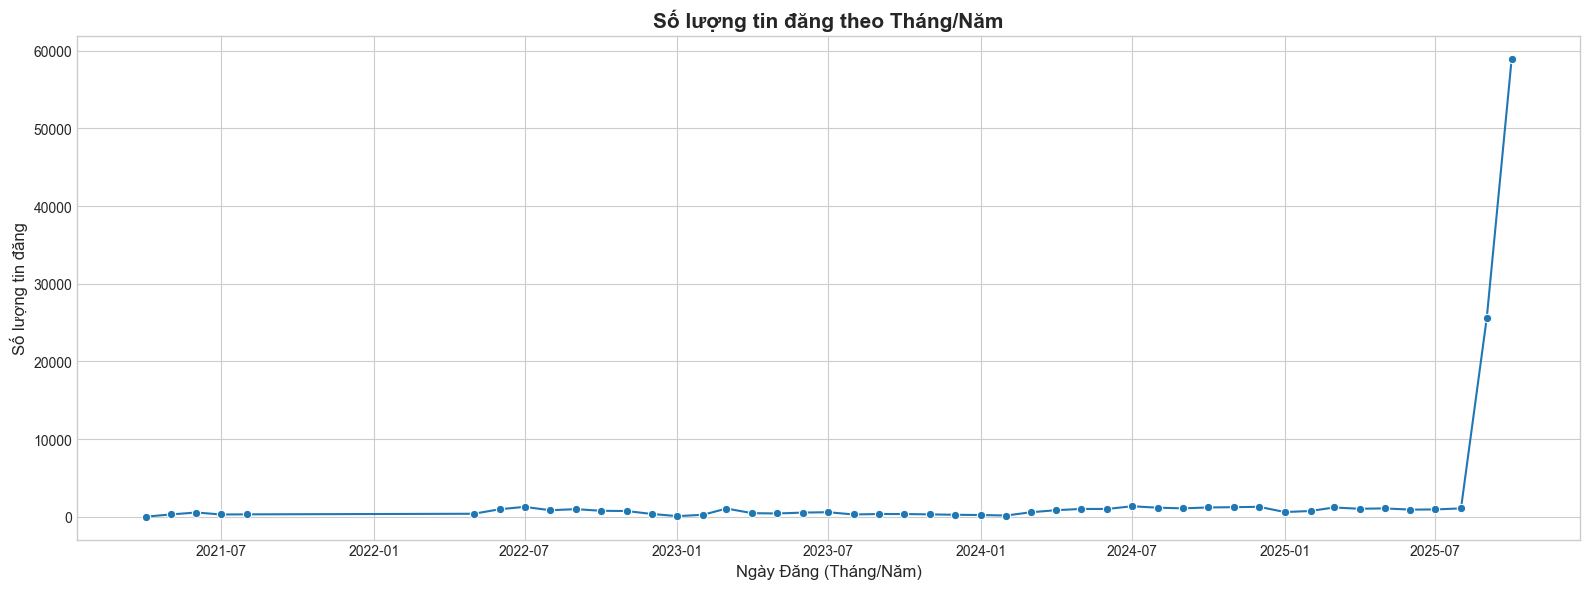

In [ ]:
# Biểu đồ 1: Số lượng tin đăng theo thời gian
if not time_stats.empty:
    plt.figure(figsize=(16, 6)) 
    sns.lineplot(data=time_stats, x='NamThang', y='SoLuongTin', marker='o')
    plt.title('Số lượng tin đăng theo Tháng/Năm', fontsize=15, weight='bold')
    plt.xlabel('Ngày Đăng (Tháng/Năm)', fontsize=12)
    plt.ylabel('Số lượng tin đăng', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu 'time_stats' để vẽ biểu đồ.")

* Nhận xét
    * Số lượng đăng tin 2025 rất lớn (~60k)
    * Số tin tăng nhẹ từ 2024 - 2025

### **6.3 Trực quan hóa: Tổng giá (Gia) trung vị theo thời gian**

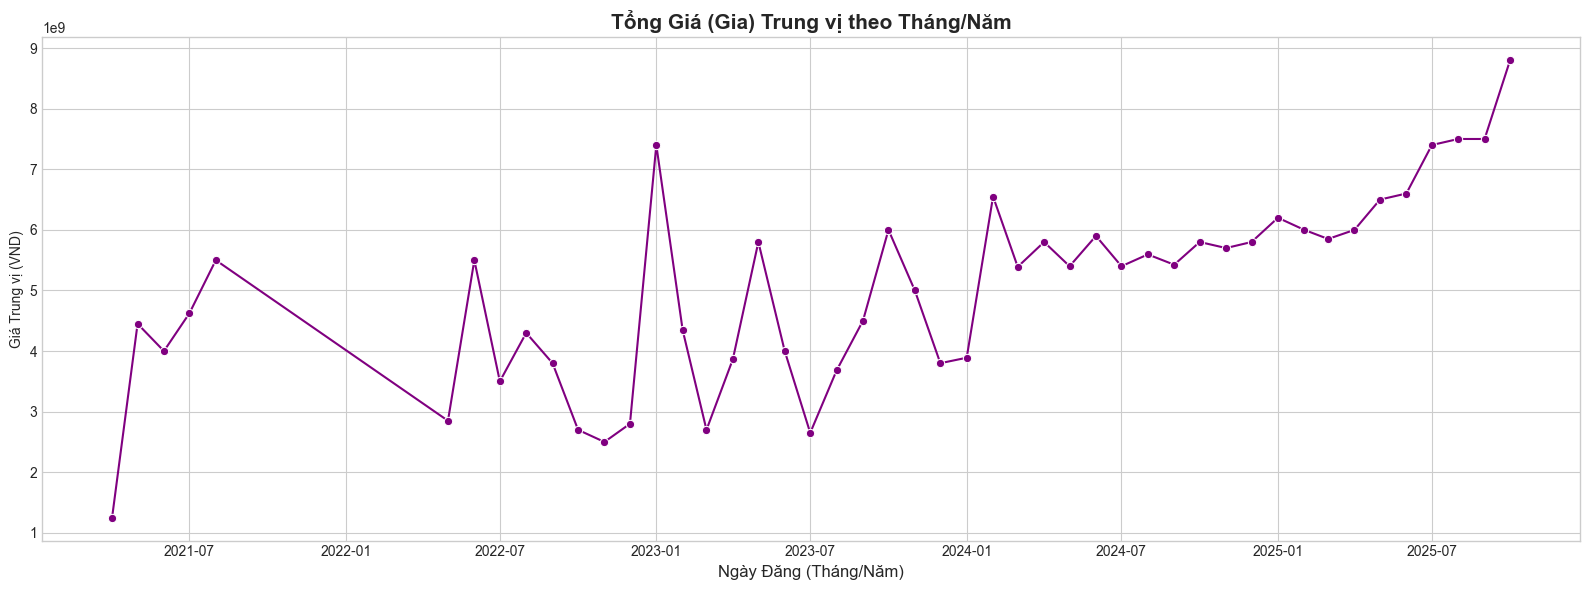

In [ ]:
# Biểu đồ 2: Tổng giá (Gia) trung vị theo thời gian
if not time_stats.empty:
    plt.figure(figsize=(16, 6)) 
    sns.lineplot(data=time_stats, x='NamThang', y='GiaTrungVi', marker='o', color='purple')
    plt.title('Tổng Giá (Gia) Trung vị theo Tháng/Năm', fontsize=15, weight='bold')
    plt.xlabel('Ngày Đăng (Tháng/Năm)', fontsize=12)
    plt.ylabel('Giá Trung vị (VND)')
    # plt.yscale('log') # Có thể cần dùng thang log nếu biến động mạnh
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu 'time_stats' để vẽ biểu đồ.")

* Nhận xét
    * Xu hướng tăng khá rõ từ 2024 đến 2025
    * Có điểm nhọn 01/2023 vọt lên ~ 7.5e9
    

### **6.4 Trực quan hóa: Đơn giá (Gia_m2) trung vị theo thời gian**

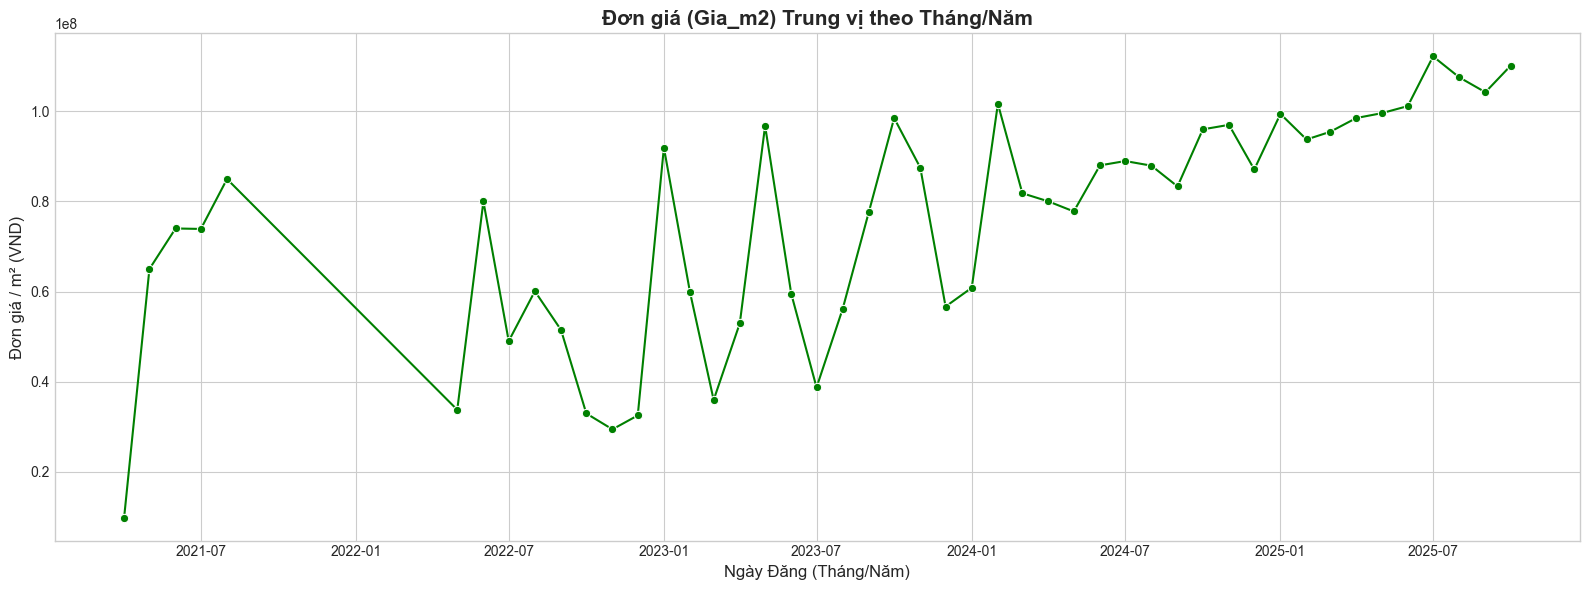

In [ ]:
# Biểu đồ 3: Đơn giá (Gia_m2) trung vị theo thời gian
if not time_stats.empty:
    plt.figure(figsize=(16, 6)) 
    sns.lineplot(data=time_stats, x='NamThang', y='GiaM2TrungVi', marker='o', color='green')
    plt.title('Đơn giá (Gia_m2) Trung vị theo Tháng/Năm', fontsize=15, weight='bold')
    plt.xlabel('Ngày Đăng (Tháng/Năm)', fontsize=12)
    plt.ylabel('Đơn giá / m² (VND)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu 'time_stats' để vẽ biểu đồ.")

* Nhận xét
    * Xu hướng tăng đều hơn về tổng giá
    * 2025 có mức giá cao nhất, tăng dần từ 2024
    * Có vài tháng tăng mạnh rồi bậc lên

### **6.5 Phân tích tỷ lệ LoaiBDS trong từng QuanHuyen (Top 5 quận phổ biến nhất)**


--- Phân tích tỷ lệ LoaiBDS trong 5 Quận/Huyện phổ biến nhất ---

Bảng tỷ lệ (%) Loại BĐS theo Quận:


LoaiBDS,Biệt thự,Căn hộ,Không xác định,Nhà,Đất
QuanHuyen,,,,,
Bình Tân,2.4,5.4,8.2,66.9,17.0
Gò Vấp,3.1,5.5,9.5,66.7,15.2
Quận 7,7.9,27.2,11.2,44.2,9.5
Thủ Đức,7.5,12.4,11.1,41.8,27.2
Tân Bình,2.6,7.5,10.0,73.4,6.5


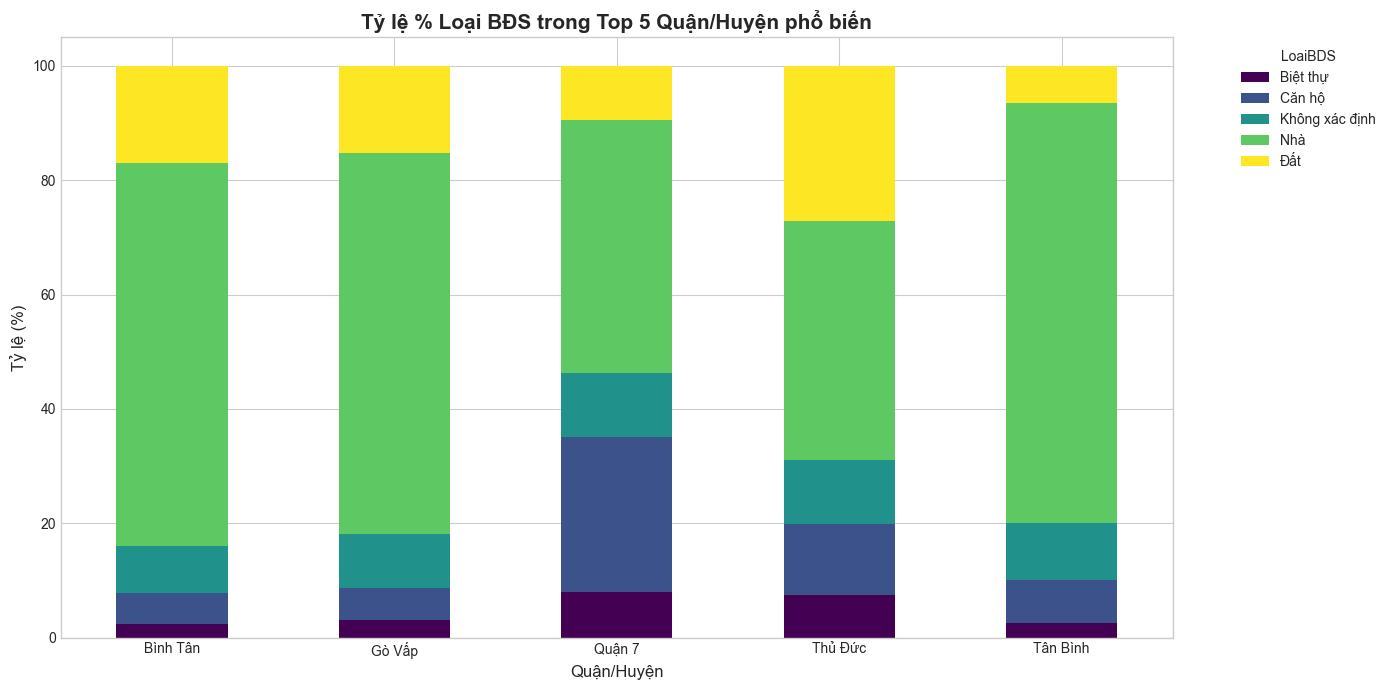

In [ ]:
# Phân tích tỷ lệ LoaiBDS trong từng QuanHuyen (Top 5 quận phổ biến nhất)

if 'QuanHuyen' in df_eda.columns and 'LoaiBDS' in df_eda.columns:
    print("\n--- Phân tích tỷ lệ LoaiBDS trong 5 Quận/Huyện phổ biến nhất ---")
    
    # Lấy top 5 quận phổ biến (từ Nhiệm vụ 3)
    try:
        top_5_quan = df_eda['QuanHuyen'].value_counts().iloc[:5].index
        
        # Lọc df chỉ chứa top 5 quận
        df_top5_quan = df_eda[df_eda['QuanHuyen'].isin(top_5_quan)]
        
        # Tạo bảng crosstab (đếm số lượng)
        cross_tab_count = pd.crosstab(df_top5_quan['QuanHuyen'], df_top5_quan['LoaiBDS'])
        
        # Chuyển sang % theo hàng (normalize='index')
        cross_tab_percent = pd.crosstab(df_top5_quan['QuanHuyen'], df_top5_quan['LoaiBDS'], normalize='index') * 100
        
        print("\nBảng tỷ lệ (%) Loại BĐS theo Quận:")
        display(cross_tab_percent.round(1))
        
        # Vẽ biểu đồ thanh chồng (stacked bar chart)
        cross_tab_percent.plot(kind='bar', stacked=True, figsize=(14, 7), cmap='viridis')
        plt.title('Tỷ lệ % Loại BĐS trong Top 5 Quận/Huyện phổ biến', fontsize=15, weight='bold')
        plt.xlabel('Quận/Huyện', fontsize=12)
        plt.ylabel('Tỷ lệ (%)', fontsize=12)
        plt.xticks(rotation=0)
        plt.legend(title='LoaiBDS', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Lỗi khi thực hiện phân tích chéo: {e}")

* Nhận xét
    * Nhà chiếm da số hầu hết Top 5 quận
    * Đất có tỷ trọng cao ở Thủ Đức
    * Căn hộ nổi bậc nhất ở Quận 7 
    * Không xác định chiến khoảng 8 ~ 11%